In [1]:
#!/usr/bin/env python3
"""
Evaluate model performance from a predictions CSV file.

Usage:
    python evaluate_model.py /path/to/predictions.csv [--threshold 0.1]
"""

import argparse
import pandas as pd
import numpy as np
import re
import ast
import json
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    confusion_matrix, roc_curve, auc
)


def is_test_case(filename):
    """Detect if a filename is a test case based on specific patterns."""
    test_patterns = [
        r'^arup\s+TEST\b',
        r'^ARUPTEST\b',
        r'^SS\s+TEST\b',
        r'^ZZTEST\b',
        r'^TEST\s+\d+',
    ]
    for pattern in test_patterns:
        if re.search(pattern, filename, re.IGNORECASE):
            return True
    return False


def extract_json_values(result_string):
    """Extract disease_burden_pct and viability_pct from the Result column."""
    try:
        match = re.search(r'<final>(.*?)</final>', result_string, re.DOTALL)
        if match:
            json_str = match.group(1).strip()
            data = json.loads(json_str)
            return data.get('disease_burden_pct'), data.get('viability_pct')
        else:
            return None, None
    except (json.JSONDecodeError, AttributeError, TypeError):
        return None, None


def load_and_preprocess_data(results_csv_path):
    """Load all required data and perform preprocessing."""
    
    # Load fixed datasets
    new_test = pd.read_csv('/home/32210/test_things/lmd_conversion/updated_test_set_09052025_withreports.csv')
    ollama_results_test = pd.read_csv('/home/32210/test_things/lmd_conversion/results_ollama_test.csv')
    viability_model_results = pd.read_csv('/home/32210/git/dinoflow/predictions_20251023_164239.csv')
    
    # Load the model predictions (variable input)
    results = pd.read_csv(results_csv_path)
    
    # Filter out test cases
    list_of_test_set_accessions = []
    for idx, row in new_test.iterrows():
        list_of_strings = ast.literal_eval(row['fil'])
        leni = len(list_of_strings)
        counti = 0
        for el in list_of_strings:
            if is_test_case(el):
                counti += 1
        if counti == leni:
            list_of_test_set_accessions.append(row['ACCESSION'])
    
    new_test = new_test[~new_test['ACCESSION'].isin(list_of_test_set_accessions)]
    
    # Correct sample type mismatches
    pattern_bm = r'(SAMPLE|SPECIMEN)\s*:\s*BONE\s+MARROW'
    pattern_pb = r'(SAMPLE|SPECIMEN)\s*:\s*PERIPHERAL\s+BLOOD'
    
    error_pb = []
    error_bm = []
    for idx, row in new_test.iterrows():
        if re.search(pattern_bm, row['chart_text'], re.IGNORECASE) and row['sample_type'] == 'PERIPHERAL BLOOD':
            error_pb.append(row['ACCESSION'])
        if re.search(pattern_pb, row['chart_text'], re.IGNORECASE) and row['sample_type'] == 'BONE MARROW':
            error_bm.append(row['ACCESSION'])
    
    for ac in error_pb:
        new_test.loc[new_test['ACCESSION'] == ac, 'sample_type'] = 'BONE MARROW'
    for ac in error_bm:
        new_test.loc[new_test['ACCESSION'] == ac, 'sample_type'] = 'PERIPHERAL BLOOD'
    
    # Merge with predictions
    new_test_with_preds = new_test.merge(results, left_on='ACCESSION', right_on='accession', how='left')
    new_test_with_preds = new_test_with_preds[new_test_with_preds['sample_type'] == 'PERIPHERAL BLOOD'].copy()
    
    # Extract ollama results
    ollama_results_test[['disease_burden', 'viability']] = ollama_results_test['Result'].apply(
        lambda x: pd.Series(extract_json_values(x))
    )
    new_test_with_preds = new_test_with_preds.merge(
        ollama_results_test, left_on='ACCESSION', right_on='ACCESSION', how='left'
    ).copy()
    new_test_with_preds = new_test_with_preds[~new_test_with_preds['accession'].isna()].copy()
    
    # Merge viability model results
    viability_model_results['extracted_ACCESSION'] = viability_model_results['ACCESSION'].str.extract(r'\((\d+)\)').astype(int)
    new_test_with_preds = new_test_with_preds[new_test_with_preds['sample_type'] == 'PERIPHERAL BLOOD'].copy()
    new_test_with_preds = new_test_with_preds.merge(
        viability_model_results, left_on='ACCESSION', right_on='extracted_ACCESSION', how='left'
    ).copy()
    new_test_with_preds = new_test_with_preds[new_test_with_preds['viability'].notna()].copy()
    
    new_test_with_preds['viab_GT_80'] = new_test_with_preds['predicted_value'] > 80
    new_test_with_preds['gold_viab_GT_80'] = new_test_with_preds['viability'] > 80
    
    # Limit to first 5000 samples (as in notebook)
    new_test_with_preds = new_test_with_preds.iloc[0:5000].copy()
    
    return new_test_with_preds


def apply_conditions_and_create_labels(df):
    """Apply filtering conditions and create final labels."""
    
    condition_1 = (~df['accession'].isna())
    condition_2 = (df['sample_type'] == 'PERIPHERAL BLOOD')
    condition_4 = (df['ADD_ON'] == True)
    condition_5 = ~(df[['10+BNHL', '5+BNHL', '5-10-BNHL', 'AML', 'BALL', 'CLL', 'Clotted', 'Eos',
                        'HCL', 'Hemodilute', 'High48Ratio', 'LGL', 'Left Shift', 'MastCell',
                        'Monocytic', 'Myeloid', 'NK', 'No20', 'PNH', 'Paucicellular',
                        'PlasmaCell', 'Reversed48Ratio', 'Sezary', 'Suboptimal', 'TALL',
                        'TLPD', 'Weak33']].any(axis=1))
    condition_6 = (df['disease_burden'] == 0)
    
    test_set = df[condition_1 & condition_2 & ~(condition_4 & condition_6 & condition_5)].copy()
    
    viab_col = 'predicted_value'
    
    # this name is misleading, it's not the final normal, it's is actually FINAL ABNORMAL
    test_set['FINAL_NORMAL'] = np.where(
        test_set['ACTION_REQUIRED'],
        True,
        ~(test_set[viab_col] > 85)
    )
    
    test_set['FINAL_PREDICTED_NORMAL'] = np.where(
        test_set['mean_probability'] > 0.1,
        True,
        ~(test_set[viab_col] > 85)
    )
    
    test_set['FINAL_MODEL_SCORE'] = np.where(
        test_set['predicted_value'] < 85,
        1.0,
        test_set['mean_probability']
    )
    
    return test_set


def compute_performance_metrics(df, threshold=0.1):
    """Compute and print performance metrics at a given threshold."""
    
    true_pos = df[(df['FINAL_MODEL_SCORE'] > threshold) & (df['FINAL_NORMAL'] == True)]
    false_neg = df[(df['FINAL_MODEL_SCORE'] < threshold) & (df['FINAL_NORMAL'] == True)]
    false_pos = df[(df['FINAL_MODEL_SCORE'] > threshold) & (df['FINAL_NORMAL'] == False)]
    true_neg = df[(df['FINAL_MODEL_SCORE'] < threshold) & (df['FINAL_NORMAL'] == False)]
    
    l_tp, l_fn, l_fp, l_tn = len(true_pos), len(false_neg), len(false_pos), len(true_neg)
    
    recall = l_tp / (l_tp + l_fn) if (l_tp + l_fn) > 0 else 0
    precision = l_tp / (l_tp + l_fp) if (l_tp + l_fp) > 0 else 0
    specificity = l_tn / (l_tn + l_fp) if (l_tn + l_fp) > 0 else 0
    npv = l_tn / (l_tn + l_fn) if (l_tn + l_fn) > 0 else 0
    f1 = 2 * l_tp / (2 * l_tp + l_fp + l_fn) if (2 * l_tp + l_fp + l_fn) > 0 else 0
    
    # Compute ROC AUC
    y_true = df['FINAL_NORMAL'].astype(int)
    y_scores = df['FINAL_MODEL_SCORE']
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    print(f"\n{'='*50}")
    print(f"Performance Metrics (threshold={threshold})")
    print(f"{'='*50}")
    print(f"TP: {l_tp}, FN: {l_fn}, FP: {l_fp}, TN: {l_tn}")
    print(f"Recall:      {recall:.3f}")
    print(f"Precision:   {precision:.3f}")
    print(f"Specificity: {specificity:.3f}")
    print(f"NPV:         {npv:.3f}")
    print(f"F1:          {f1:.3f}")
    print(f"ROC AUC:     {roc_auc:.3f}")
    print(f"{'='*50}")
    
    return {
        'threshold': threshold,
        'tp': l_tp, 'fn': l_fn, 'fp': l_fp, 'tn': l_tn,
        'recall': recall, 'precision': precision,
        'specificity': specificity, 'npv': npv, 'f1': f1,
        'roc_auc': roc_auc
    }

In [2]:
 # Load and preprocess
df = load_and_preprocess_data('/home/32210/git/dinoflow/scripts/my_evaluation_oct2325_predictions.csv')
print(f"Loaded {len(df)} samples after initial preprocessing")

# Apply conditions and create labels
current_model_set = apply_conditions_and_create_labels(df)
print(f"Final test set size: {len(current_model_set)} samples")

Loaded 5000 samples after initial preprocessing
Final test set size: 4660 samples


In [3]:
 # Load and preprocess
df = load_and_preprocess_data('/home/32210/git/dinoflow/scripts/contrast_eval_results_predictions.csv')
print(f"Loaded {len(df)} samples after initial preprocessing")

# Apply conditions and create labels
first_alex_set = apply_conditions_and_create_labels(df)
print(f"Final test set size: {len(first_alex_set)} samples")

Loaded 5000 samples after initial preprocessing
Final test set size: 4660 samples


In [4]:
 # Load and preprocess
df = load_and_preprocess_data('/home/32210/git/dinoflow/scripts/contrast_eval_results_epoch54_predictions.csv')
print(f"Loaded {len(df)} samples after initial preprocessing")

# Apply conditions and create labels
epoch_54_set = apply_conditions_and_create_labels(df)
print(f"Final test set size: {len(epoch_54_set)} samples")

Loaded 5000 samples after initial preprocessing
Final test set size: 4660 samples


In [5]:
 # Load and preprocess
df = load_and_preprocess_data('/home/32210/git/dinoflow/scripts/contrast_eval_results_epoch57_predictions.csv')
print(f"Loaded {len(df)} samples after initial preprocessing")

# Apply conditions and create labels
epoch_57_set = apply_conditions_and_create_labels(df)
print(f"Final test set size: {len(epoch_57_set)} samples")

Loaded 5000 samples after initial preprocessing
Final test set size: 4660 samples


In [6]:
 # Load and preprocess
df = load_and_preprocess_data('/home/32210/git/dinoflow/scripts/contrast_eval_results_epoch57_v2_predictions.csv')
print(f"Loaded {len(df)} samples after initial preprocessing")

# Apply conditions and create labels
epoch_57_v2_set = apply_conditions_and_create_labels(df)
print(f"Final test set size: {len(epoch_57_v2_set)} samples")

Loaded 5000 samples after initial preprocessing
Final test set size: 4660 samples


In [7]:
import matplotlib.pyplot as plt

def plot_false_normals(df, model_name):
    data_dict=df[(df['FINAL_NORMAL']==True) & (df['FINAL_PREDICTED_NORMAL']==False)][['10+BNHL', '5+BNHL', '5-10-BNHL',
       'AML', 'BALL', 'CLL', 'Clotted', 'Eos',
        'HCL',  'Hemodilute', 'High48Ratio', 'LGL',
       'Left Shift', 'MastCell', 'Monocytic', 'Myeloid', 'NK', 'No20', 
       'PNH', 'Paucicellular', 'PlasmaCell', 'Reversed48Ratio', 'Sezary',
       'Suboptimal', 'TALL', 'TLPD', 'Weak33']].sum().to_dict()

    # Sort dictionary by values (descending order)
    sorted_data = dict(sorted(data_dict.items(), key=lambda x: x[1], reverse=True))

    # Create histogram with sorted data
    plt.figure(figsize=(10, 6))
    plt.bar(sorted_data.keys(), sorted_data.values())
    plt.xlabel('Diagnosis')
    plt.ylabel('Count')
    plt.title(f'Histogram of false normals for {model_name}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [8]:
#plot_false_normals(current_model_set, 'current_model_set')

In [19]:
#plot_false_normals(current_model_set, 'first_alex_set')

In [23]:
#plot_false_normals(current_model_set, 'epoch_54_set')

In [21]:
#plot_false_normals(current_model_set, 'epoch_57_set')

In [22]:
#plot_false_normals(current_model_set, 'epoch_57_v2_set')

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_disease_burden(df, model_name):

    clasi=['10+BNHL', '5+BNHL', '5-10-BNHL',
    'AML', 'BALL', 'CLL', 'Clotted', 'Eos',
    'HCL',  'Hemodilute', 'High48Ratio', 'LGL',
    'Left Shift', 'MastCell', 'Monocytic', 'Myeloid', 'NK', 'No20', 
    'PNH', 'Paucicellular', 'PlasmaCell', 'Reversed48Ratio', 'Sezary',
    'Suboptimal', 'TALL', 'TLPD', 'Weak33']

    dictio_disease_burden={}
    for cl in clasi:
        # dictio_disease_burden[cl]=df[(df['FINAL_NORMAL']==True) & (df['mean_probability']<0.2) & (df['disease_burden']>=0) & (df['predicted_value']>85) & (df[cl]==True)][['10+BNHL', '5+BNHL', '5-10-BNHL',
        # 'AML', 'BALL', 'CLL', 'Clotted', 'Eos',
        #     'HCL',  'Hemodilute', 'High48Ratio', 'LGL',
        # 'Left Shift', 'MastCell', 'Monocytic', 'Myeloid', 'NK', 'No20', 
        # 'PNH', 'Paucicellular', 'PlasmaCell', 'Reversed48Ratio', 'Sezary',
        # 'Suboptimal', 'TALL', 'TLPD', 'Weak33', 'disease_burden', 'chart_text_x','ACCESSION_x']]['disease_burden'].tolist()

        dictio_disease_burden[cl]=df[(df['FINAL_NORMAL']==True) & (df['FINAL_MODEL_SCORE']<0.2) & (df['disease_burden']>=0) & (df[cl]==True)][['10+BNHL', '5+BNHL', '5-10-BNHL',
        'AML', 'BALL', 'CLL', 'Clotted', 'Eos',
            'HCL',  'Hemodilute', 'High48Ratio', 'LGL',
        'Left Shift', 'MastCell', 'Monocytic', 'Myeloid', 'NK', 'No20', 
        'PNH', 'Paucicellular', 'PlasmaCell', 'Reversed48Ratio', 'Sezary',
        'Suboptimal', 'TALL', 'TLPD', 'Weak33', 'disease_burden', 'chart_text_x','ACCESSION_x']]['disease_burden'].tolist()


    data_dict = {
        # ... your dictionary
    }

    # Convert to DataFrame
    data_list = []
    for key, values in dictio_disease_burden.items():
        if key=='Weak33' or key=='CLL_Class' or key=='Suboptimal' or key=='ADD_ON' or key=='CLL_Class':
            continue
        for value in values:
            if key=='Left Shift' and value!=0:
                value=0
            if value==0:
                value+=0.00001
            data_list.append({'Category': key, 'Value': value})

    df = pd.DataFrame(data_list)

    print(df)

    # Create plot
    fig, ax = plt.subplots(figsize=(15, 6))
    sns.stripplot(data=df, x='Category', y='Value', alpha=0.6, size=8, ax=ax)
    ax.set_xlabel('Diagnosis')
    ax.set_ylabel('Disease burden percent (log scale)')
    ax.set_title(f"Disease burden distribution of false negative cases by diagnosis for {model_name}")
    ax.set_yscale('log')  # This makes the y-axis logarithmic

    # Set custom y-axis ticks
    custom_ticks = [1e-5, 0.0001, 0.001, 0.01, 0.1, 1, 5, 10, 50, 100]
    ax.set_yticks(custom_ticks)
    ax.set_yticklabels(['0','0.0001', '0.001', '0.01', '0.1', '1', '5', '10', '50', '100'])

    # Note: 0 cannot be displayed on a log scale, so it's excluded from the ticks

    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

        


         Category     Value
0         10+BNHL   0.03000
1          5+BNHL   0.20000
2       5-10-BNHL   0.06000
3       5-10-BNHL   0.10000
4       5-10-BNHL   0.50000
5       5-10-BNHL   2.00000
6       5-10-BNHL   0.07400
7       5-10-BNHL   0.40000
8       5-10-BNHL   0.20000
9       5-10-BNHL   0.20000
10            CLL   0.02000
11            CLL   0.06000
12            CLL   0.10000
13            CLL   0.01000
14            CLL   0.01000
15            CLL   0.00001
16            LGL   1.90000
17            LGL   0.90000
18            LGL   2.00000
19            LGL   2.00000
20            LGL   5.50000
21     Left Shift   0.00001
22     Left Shift   0.00001
23     Left Shift   0.00001
24     Left Shift   0.00001
25     Left Shift   0.00001
26     Left Shift   0.00001
27      Monocytic  24.00000
28      Monocytic  15.00000
29      Monocytic   6.30000
30      Monocytic   4.50000
31      Monocytic   5.40000
32      Monocytic   5.20000
33      Monocytic   5.00000
34      Monocytic  2

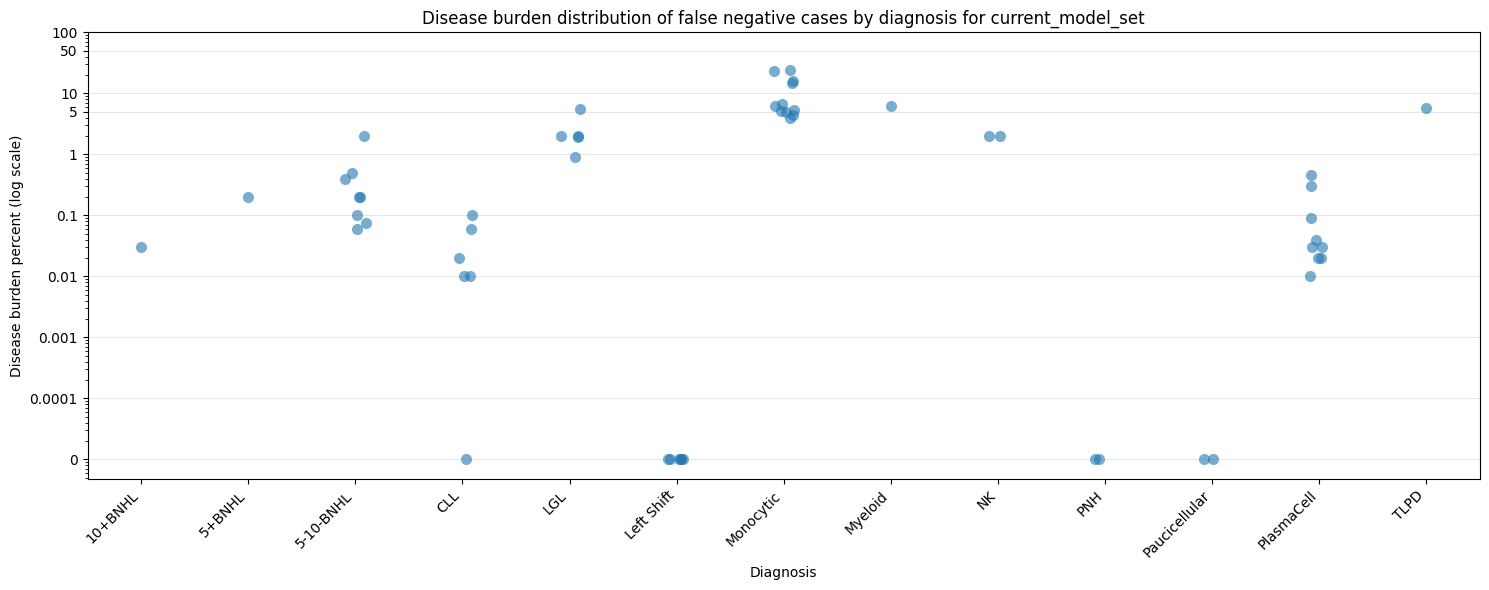


Performance Metrics (threshold=0.2)
TP: 3175, FN: 76, FP: 361, TN: 1048
Recall:      0.977
Precision:   0.898
Specificity: 0.744
NPV:         0.932
F1:          0.936
ROC AUC:     0.982
         Category     Value
0         10+BNHL   0.03000
1          5+BNHL   0.20000
2       5-10-BNHL   0.06000
3       5-10-BNHL   1.50000
4       5-10-BNHL   0.10000
5       5-10-BNHL   0.10000
6       5-10-BNHL   0.20000
7       5-10-BNHL   0.20000
8             CLL   0.02000
9             CLL   0.10000
10            CLL   0.01000
11            CLL   0.01000
12            LGL   1.90000
13            LGL   0.90000
14            LGL   2.00000
15            LGL  11.00000
16            LGL   4.00000
17     Left Shift   0.00001
18     Left Shift   0.00001
19     Left Shift   0.00001
20     Left Shift   0.00001
21     Left Shift   0.00001
22     Left Shift   0.00001
23     Left Shift   0.00001
24     Left Shift   0.00001
25      Monocytic  15.00000
26      Monocytic   6.30000
27      Monocytic   4.50000
2

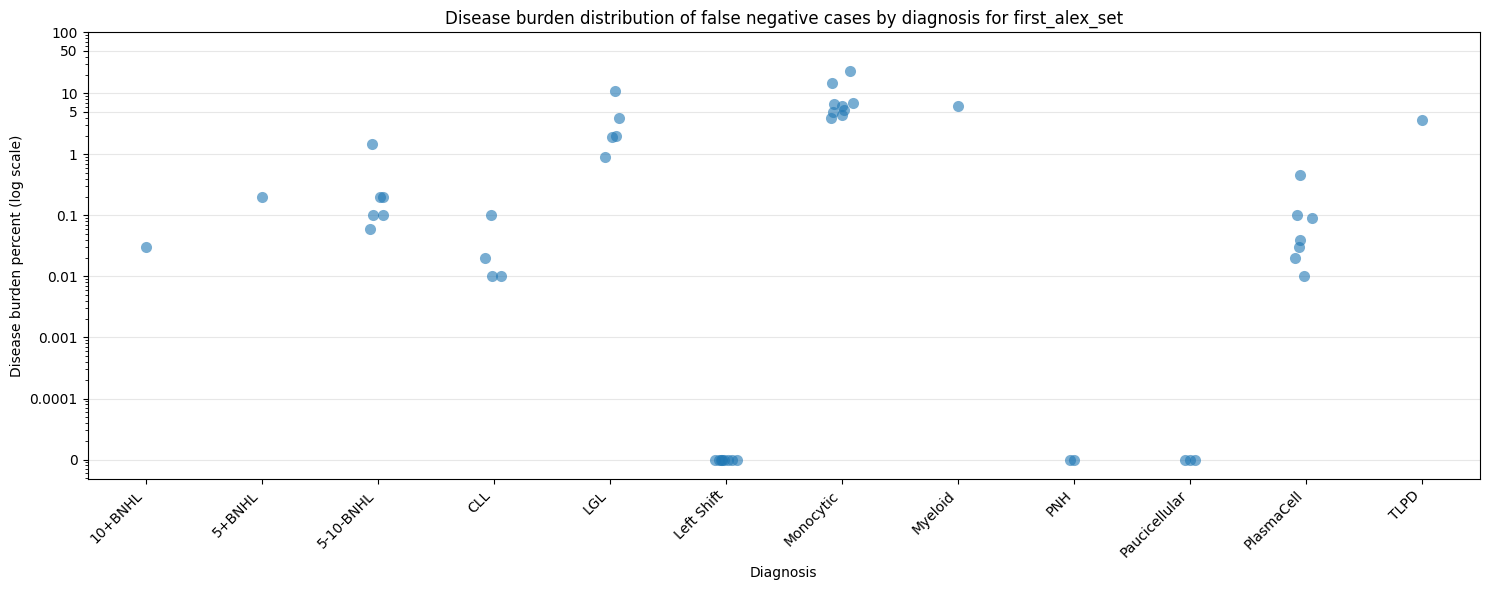


Performance Metrics (threshold=0.2)
TP: 3188, FN: 63, FP: 456, TN: 953
Recall:      0.981
Precision:   0.875
Specificity: 0.676
NPV:         0.938
F1:          0.925
ROC AUC:     0.981
         Category     Value
0         10+BNHL   0.03000
1          5+BNHL   0.20000
2       5-10-BNHL   0.06000
3       5-10-BNHL   1.50000
4       5-10-BNHL   0.10000
5       5-10-BNHL   0.20000
6             CLL   0.08000
7             CLL   0.01000
8             CLL   0.01000
9             LGL   1.90000
10            LGL   0.90000
11            LGL   2.00000
12            LGL   4.00000
13     Left Shift   0.00001
14     Left Shift   0.00001
15     Left Shift   0.00001
16      Monocytic  15.00000
17      Monocytic   4.50000
18      Monocytic   5.40000
19      Monocytic   5.00000
20      Monocytic   4.00000
21      Monocytic  21.00000
22      Monocytic  16.00000
23      Monocytic   6.60000
24  Paucicellular   0.00001
25     PlasmaCell   0.04000
26     PlasmaCell   0.02000
27     PlasmaCell   0.03000
28

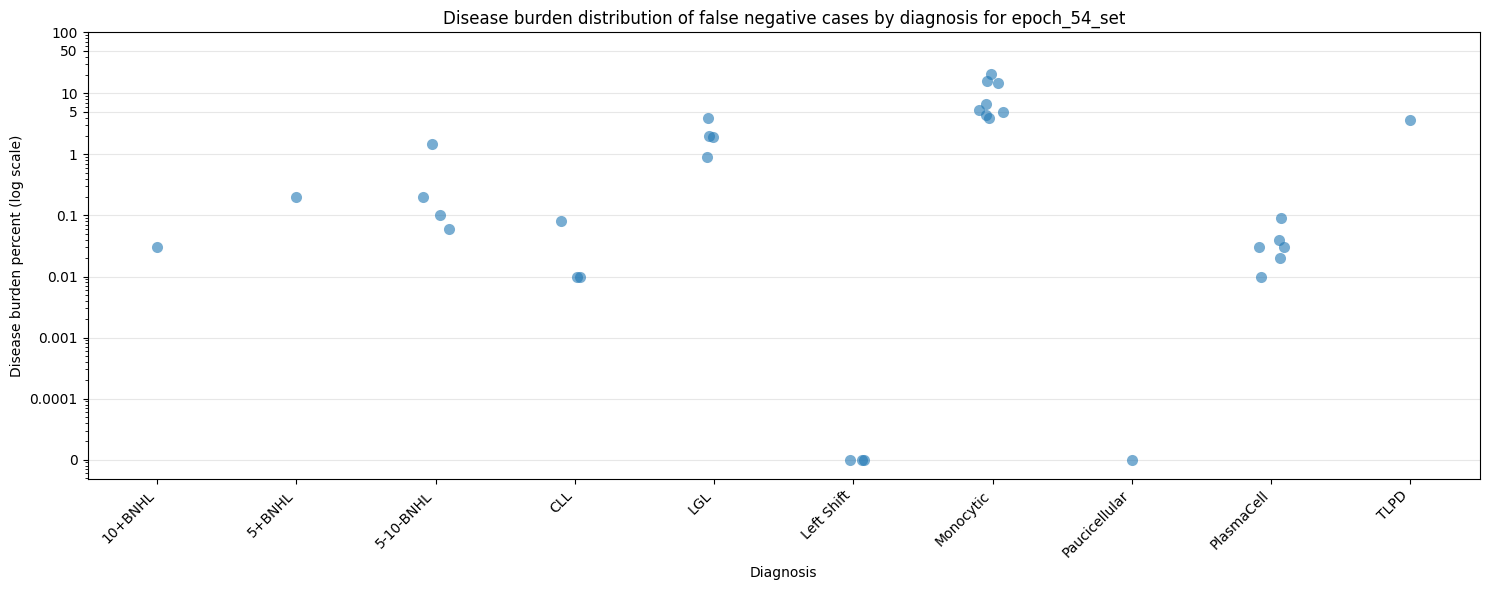


Performance Metrics (threshold=0.2)
TP: 3195, FN: 56, FP: 532, TN: 877
Recall:      0.983
Precision:   0.857
Specificity: 0.622
NPV:         0.940
F1:          0.916
ROC AUC:     0.979
      Category  Value
0      10+BNHL   0.03
1       5+BNHL   0.20
2    5-10-BNHL   1.50
3    5-10-BNHL   0.10
4    5-10-BNHL   0.10
..         ...    ...
61  PlasmaCell   6.00
62  PlasmaCell   0.01
63  PlasmaCell   0.03
64        TLPD   3.70
65        TLPD   5.70

[66 rows x 2 columns]


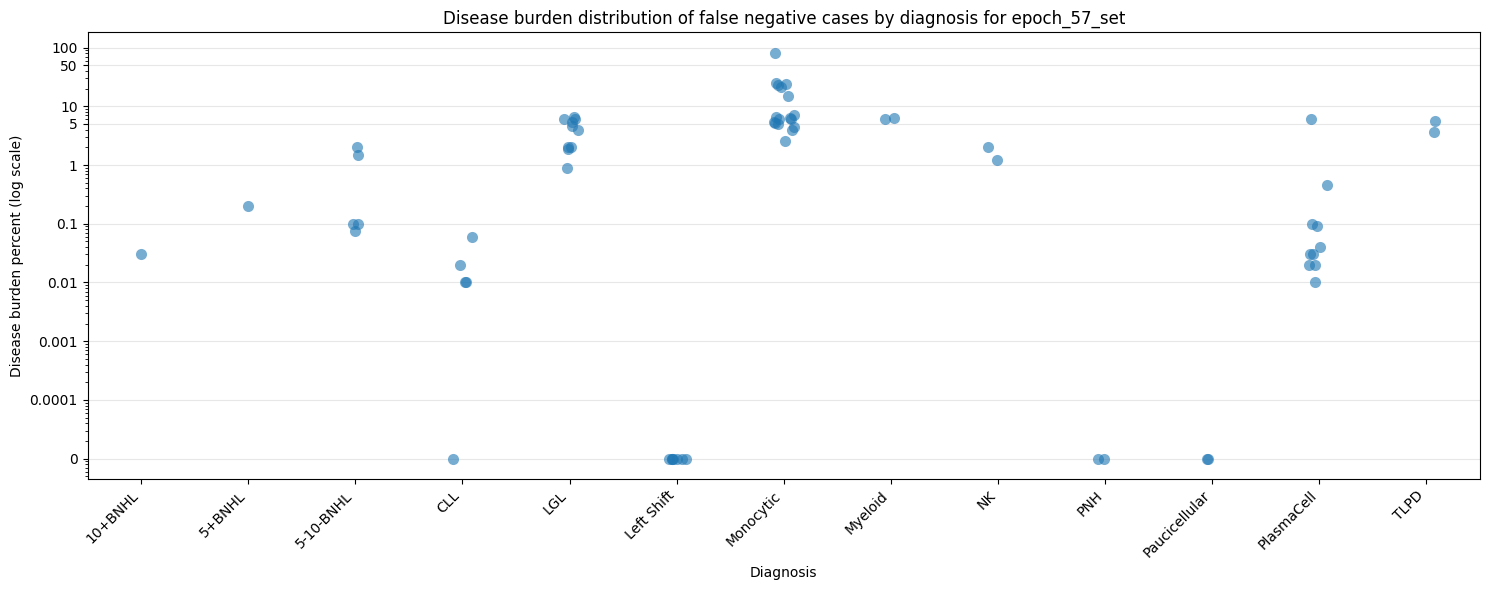


Performance Metrics (threshold=0.2)
TP: 3157, FN: 94, FP: 302, TN: 1107
Recall:      0.971
Precision:   0.913
Specificity: 0.786
NPV:         0.922
F1:          0.941
ROC AUC:     0.981
      Category  Value
0      10+BNHL   0.03
1       5+BNHL   0.20
2    5-10-BNHL   0.06
3    5-10-BNHL   1.50
4    5-10-BNHL   0.60
..         ...    ...
58  PlasmaCell   6.00
59  PlasmaCell   0.01
60  PlasmaCell   0.30
61        TLPD   3.70
62        TLPD   5.70

[63 rows x 2 columns]


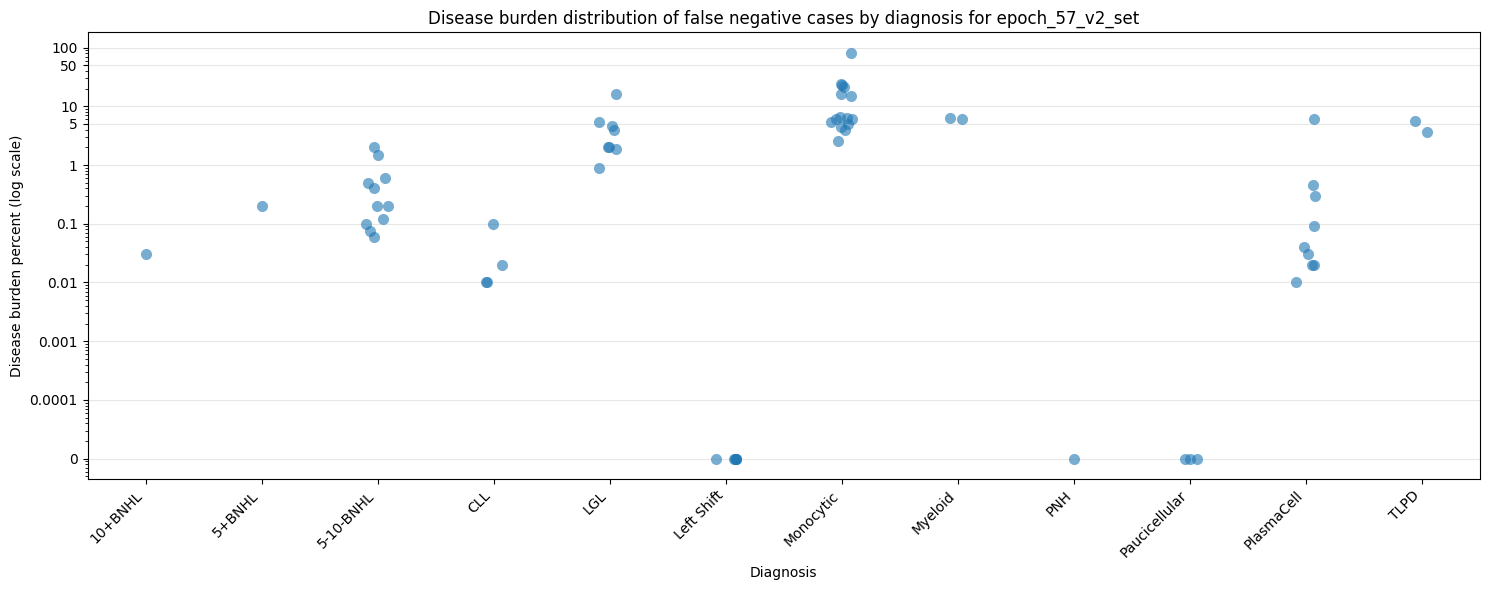


Performance Metrics (threshold=0.2)
TP: 3158, FN: 93, FP: 320, TN: 1089
Recall:      0.971
Precision:   0.908
Specificity: 0.773
NPV:         0.921
F1:          0.939
ROC AUC:     0.980


{'threshold': 0.2,
 'tp': 3158,
 'fn': 93,
 'fp': 320,
 'tn': 1089,
 'recall': 0.9713934174100277,
 'precision': 0.9079930994824612,
 'specificity': 0.772888573456352,
 'npv': 0.9213197969543148,
 'f1': 0.9386238668449992,
 'roc_auc': 0.9797190753557512}

In [9]:
plot_disease_burden(current_model_set, 'current_model_set')
compute_performance_metrics(current_model_set, threshold=0.2)
plot_disease_burden(first_alex_set, 'first_alex_set')
compute_performance_metrics(first_alex_set, threshold=0.2)
plot_disease_burden(epoch_54_set, 'epoch_54_set')
compute_performance_metrics(epoch_54_set, threshold=0.2)
plot_disease_burden(epoch_57_set, 'epoch_57_set')
compute_performance_metrics(epoch_57_set, threshold=0.2)
plot_disease_burden(epoch_57_v2_set, 'epoch_57_v2_set')
compute_performance_metrics(epoch_57_v2_set, threshold=0.2)

         Category     Value
0         10+BNHL   0.03000
1          5+BNHL   0.20000
2       5-10-BNHL   0.06000
3       5-10-BNHL   0.10000
4       5-10-BNHL   0.50000
5       5-10-BNHL   2.00000
6       5-10-BNHL   0.07400
7       5-10-BNHL   0.40000
8       5-10-BNHL   0.20000
9       5-10-BNHL   0.20000
10            CLL   0.02000
11            CLL   0.06000
12            CLL   0.10000
13            CLL   0.01000
14            CLL   0.01000
15            CLL   0.00001
16            LGL   1.90000
17            LGL   0.90000
18            LGL   2.00000
19            LGL   2.00000
20            LGL   5.50000
21     Left Shift   0.00001
22     Left Shift   0.00001
23     Left Shift   0.00001
24     Left Shift   0.00001
25     Left Shift   0.00001
26     Left Shift   0.00001
27      Monocytic  24.00000
28      Monocytic  15.00000
29      Monocytic   6.30000
30      Monocytic   4.50000
31      Monocytic   5.40000
32      Monocytic   5.20000
33      Monocytic   5.00000
34      Monocytic  2

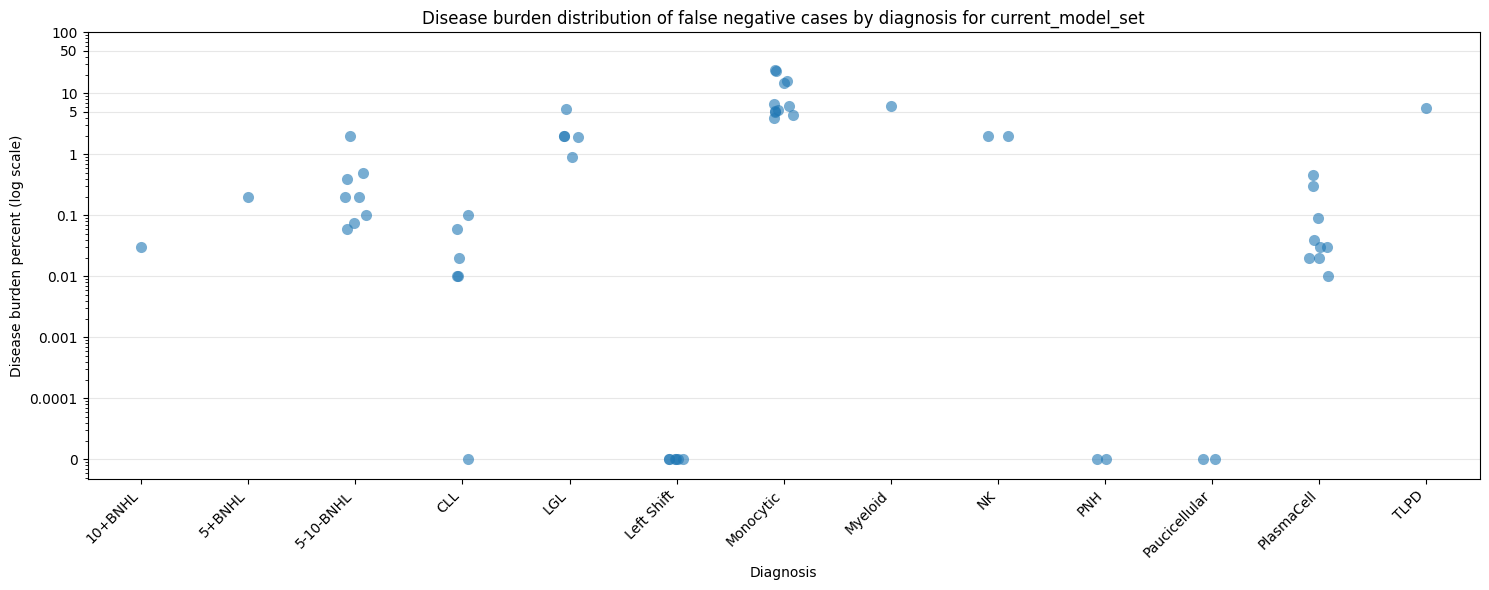


Performance Metrics (threshold=0.2)
TP: 3175, FN: 76, FP: 361, TN: 1048
Recall:      0.977
Precision:   0.898
Specificity: 0.744
NPV:         0.932
F1:          0.936
ROC AUC:     0.982
         Category     Value
0         10+BNHL   0.03000
1          5+BNHL   0.20000
2       5-10-BNHL   0.06000
3       5-10-BNHL   1.50000
4       5-10-BNHL   0.10000
5       5-10-BNHL   0.10000
6       5-10-BNHL   0.20000
7       5-10-BNHL   0.20000
8             CLL   0.02000
9             CLL   0.10000
10            CLL   0.01000
11            CLL   0.01000
12            LGL   1.90000
13            LGL   0.90000
14            LGL   2.00000
15            LGL  11.00000
16            LGL   4.00000
17     Left Shift   0.00001
18     Left Shift   0.00001
19     Left Shift   0.00001
20     Left Shift   0.00001
21     Left Shift   0.00001
22     Left Shift   0.00001
23     Left Shift   0.00001
24     Left Shift   0.00001
25      Monocytic  15.00000
26      Monocytic   6.30000
27      Monocytic   4.50000
2

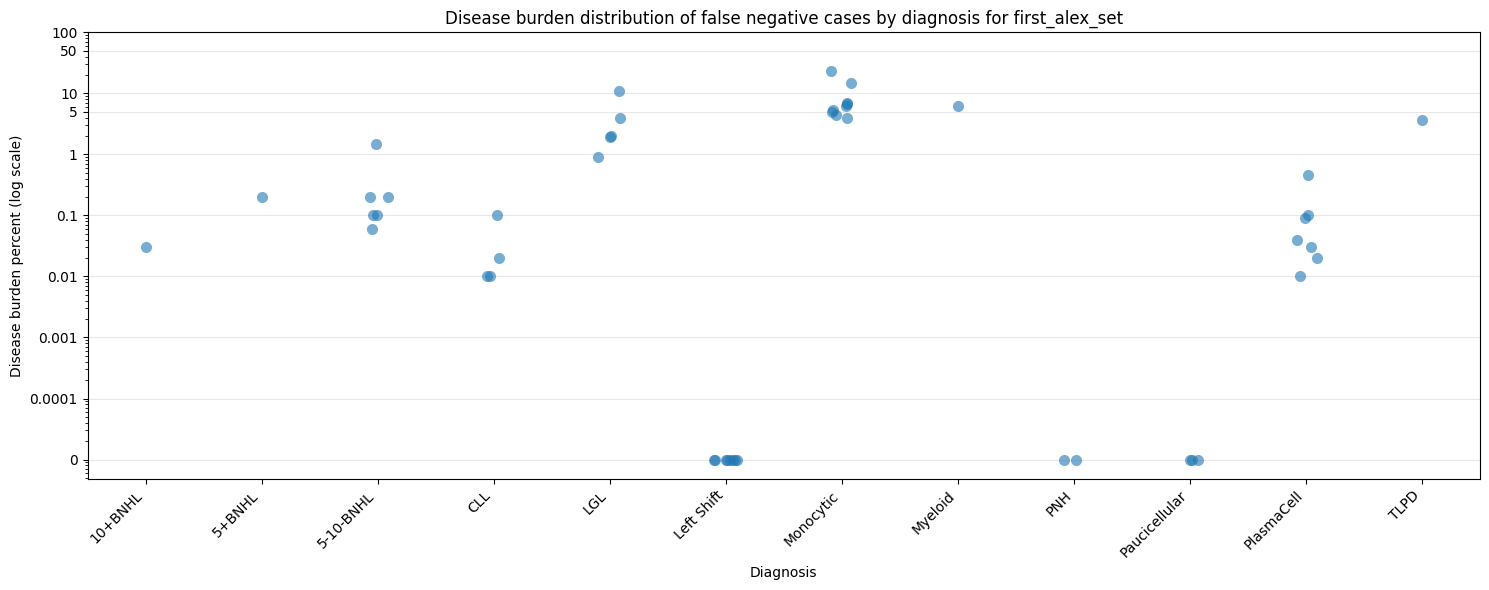


Performance Metrics (threshold=0.2)
TP: 3188, FN: 63, FP: 456, TN: 953
Recall:      0.981
Precision:   0.875
Specificity: 0.676
NPV:         0.938
F1:          0.925
ROC AUC:     0.981
         Category     Value
0         10+BNHL   0.03000
1          5+BNHL   0.20000
2       5-10-BNHL   0.06000
3       5-10-BNHL   1.50000
4       5-10-BNHL   0.10000
5       5-10-BNHL   0.20000
6             CLL   0.08000
7             CLL   0.01000
8             CLL   0.01000
9             LGL   1.90000
10            LGL   0.90000
11            LGL   2.00000
12            LGL   4.00000
13     Left Shift   0.00001
14     Left Shift   0.00001
15     Left Shift   0.00001
16      Monocytic  15.00000
17      Monocytic   4.50000
18      Monocytic   5.40000
19      Monocytic   5.00000
20      Monocytic   4.00000
21      Monocytic  21.00000
22      Monocytic  16.00000
23      Monocytic   6.60000
24  Paucicellular   0.00001
25     PlasmaCell   0.04000
26     PlasmaCell   0.02000
27     PlasmaCell   0.03000
28

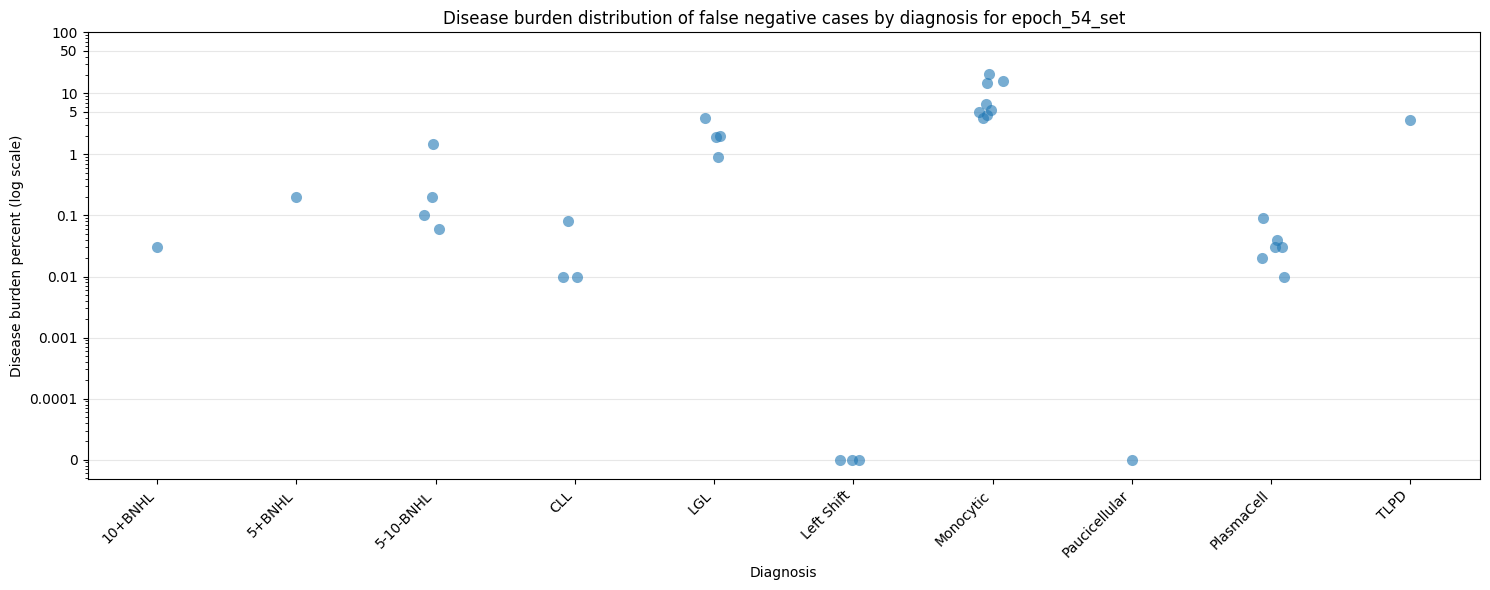


Performance Metrics (threshold=0.2)
TP: 3195, FN: 56, FP: 532, TN: 877
Recall:      0.983
Precision:   0.857
Specificity: 0.622
NPV:         0.940
F1:          0.916
ROC AUC:     0.979
      Category  Value
0      10+BNHL   0.03
1       5+BNHL   0.20
2    5-10-BNHL   1.50
3    5-10-BNHL   0.10
4    5-10-BNHL   0.10
..         ...    ...
61  PlasmaCell   6.00
62  PlasmaCell   0.01
63  PlasmaCell   0.03
64        TLPD   3.70
65        TLPD   5.70

[66 rows x 2 columns]


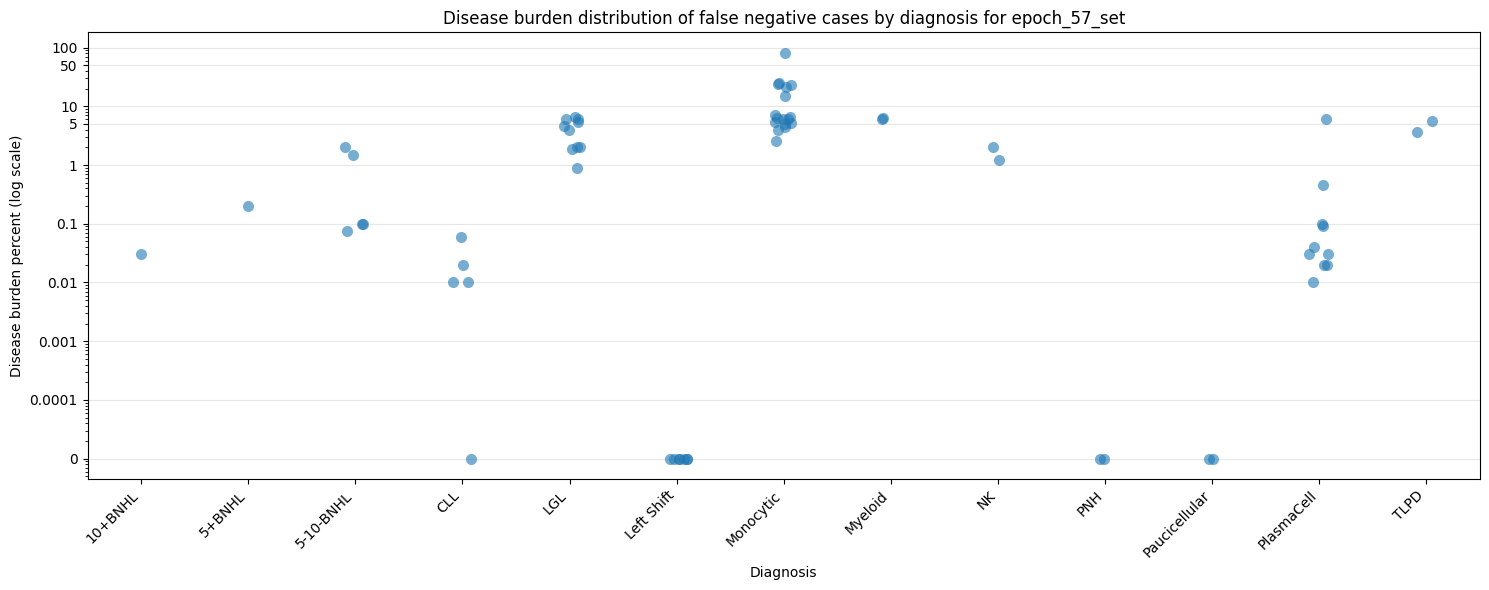


Performance Metrics (threshold=0.2)
TP: 3157, FN: 94, FP: 302, TN: 1107
Recall:      0.971
Precision:   0.913
Specificity: 0.786
NPV:         0.922
F1:          0.941
ROC AUC:     0.981
      Category  Value
0      10+BNHL   0.03
1       5+BNHL   0.20
2    5-10-BNHL   0.06
3    5-10-BNHL   1.50
4    5-10-BNHL   0.60
..         ...    ...
58  PlasmaCell   6.00
59  PlasmaCell   0.01
60  PlasmaCell   0.30
61        TLPD   3.70
62        TLPD   5.70

[63 rows x 2 columns]


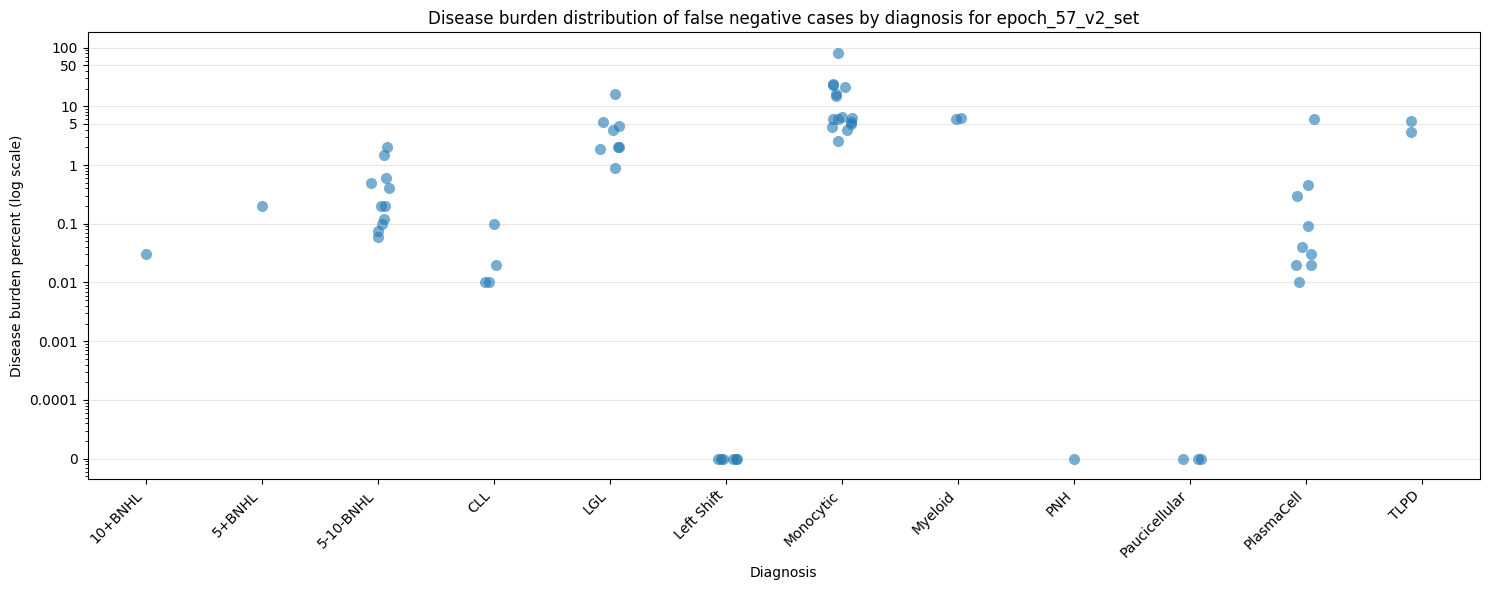


Performance Metrics (threshold=0.2)
TP: 3158, FN: 93, FP: 320, TN: 1089
Recall:      0.971
Precision:   0.908
Specificity: 0.773
NPV:         0.921
F1:          0.939
ROC AUC:     0.980


{'threshold': 0.2,
 'tp': 3158,
 'fn': 93,
 'fp': 320,
 'tn': 1089,
 'recall': 0.9713934174100277,
 'precision': 0.9079930994824612,
 'specificity': 0.772888573456352,
 'npv': 0.9213197969543148,
 'f1': 0.9386238668449992,
 'roc_auc': 0.9797190753557512}

In [25]:
plot_disease_burden(current_model_set, 'current_model_set')
compute_performance_metrics(current_model_set, threshold=0.2)
plot_disease_burden(first_alex_set, 'first_alex_set')
compute_performance_metrics(first_alex_set, threshold=0.2)
plot_disease_burden(epoch_54_set, 'epoch_54_set')
compute_performance_metrics(epoch_54_set, threshold=0.2)
plot_disease_burden(epoch_57_set, 'epoch_57_set')
compute_performance_metrics(epoch_57_set, threshold=0.2)
plot_disease_burden(epoch_57_v2_set, 'epoch_57_v2_set')
compute_performance_metrics(epoch_57_v2_set, threshold=0.2)

         Category     Value
0         10+BNHL   0.03000
1          5+BNHL   0.20000
2       5-10-BNHL   0.06000
3       5-10-BNHL   1.50000
4       5-10-BNHL   0.10000
5       5-10-BNHL   0.20000
6             CLL   0.08000
7             CLL   0.01000
8             CLL   0.01000
9             LGL   1.90000
10            LGL   0.90000
11            LGL   2.00000
12            LGL   4.00000
13     Left Shift   0.00001
14     Left Shift   0.00001
15     Left Shift   0.00001
16      Monocytic  15.00000
17      Monocytic   4.50000
18      Monocytic   5.40000
19      Monocytic   5.00000
20      Monocytic   4.00000
21      Monocytic  21.00000
22      Monocytic  16.00000
23      Monocytic   6.60000
24  Paucicellular   0.00001
25     PlasmaCell   0.04000
26     PlasmaCell   0.02000
27     PlasmaCell   0.03000
28     PlasmaCell   0.09000
29     PlasmaCell   0.01000
30     PlasmaCell   0.03000
31           TLPD   3.70000


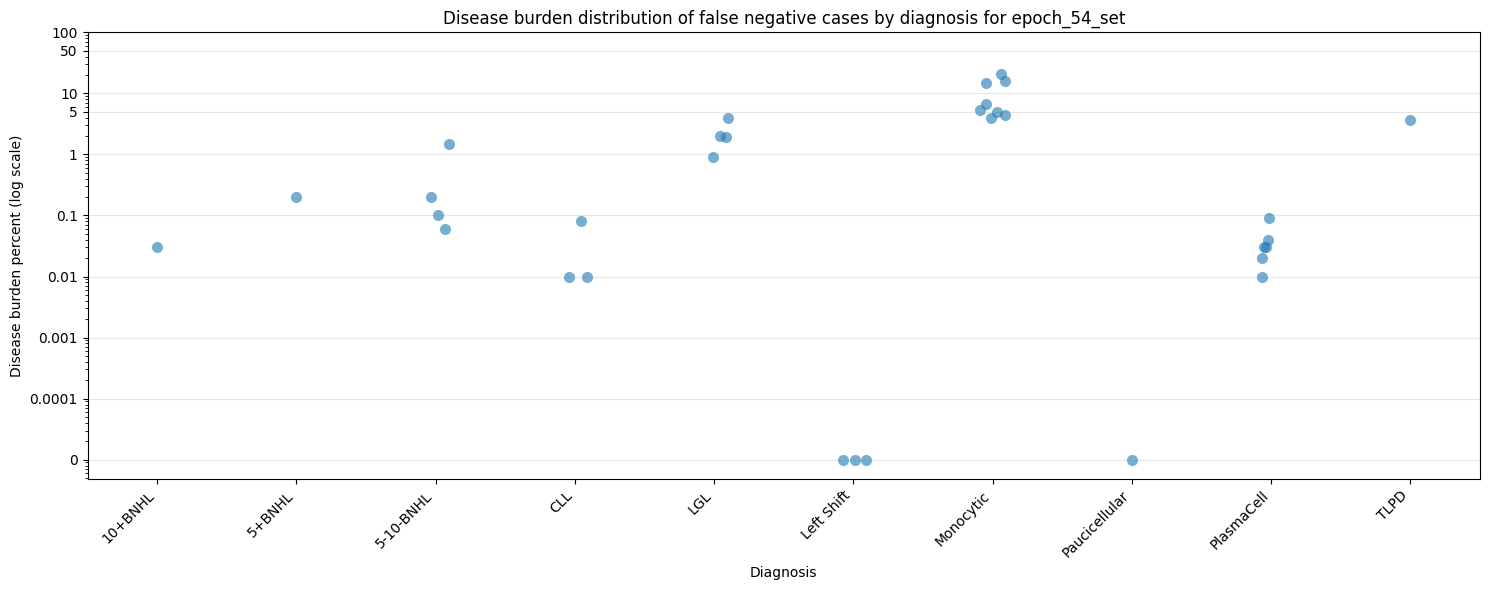

In [9]:
plot_disease_burden(epoch_54_set, 'epoch_54_set')

      Category     Value
0      10+BNHL   0.03000
1    5-10-BNHL   0.10000
2    5-10-BNHL   0.20000
3    5-10-BNHL   0.20000
4          CLL   0.01000
5          CLL   0.01000
6          LGL   0.90000
7          LGL   2.00000
8    Monocytic  15.00000
9    Monocytic   4.50000
10   Monocytic   5.40000
11   Monocytic   5.00000
12   Monocytic   4.00000
13   Monocytic   6.60000
14         PNH   0.00001
15  PlasmaCell   0.09000
16  PlasmaCell   0.01000


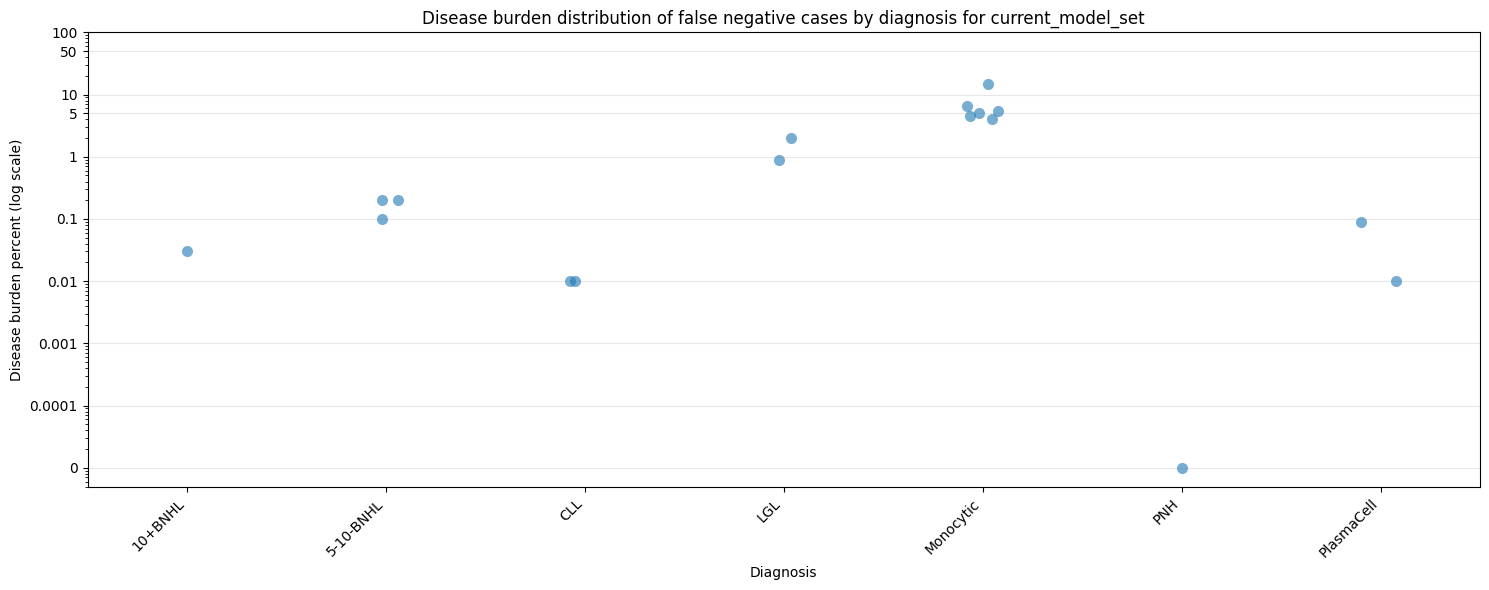


Performance Metrics (threshold=0.1)
TP: 3221, FN: 30, FP: 676, TN: 733
Recall:      0.991
Precision:   0.827
Specificity: 0.520
NPV:         0.961
F1:          0.901
ROC AUC:     0.982
         Category     Value
0         10+BNHL   0.03000
1       5-10-BNHL   0.06000
2       5-10-BNHL   0.10000
3             CLL   0.01000
4             CLL   0.01000
5             LGL   1.90000
6             LGL   0.90000
7             LGL   2.00000
8             LGL   4.00000
9      Left Shift   0.00001
10     Left Shift   0.00001
11      Monocytic  15.00000
12      Monocytic   4.50000
13      Monocytic   5.40000
14      Monocytic   6.60000
15  Paucicellular   0.00001
16     PlasmaCell   0.04000
17     PlasmaCell   0.46000


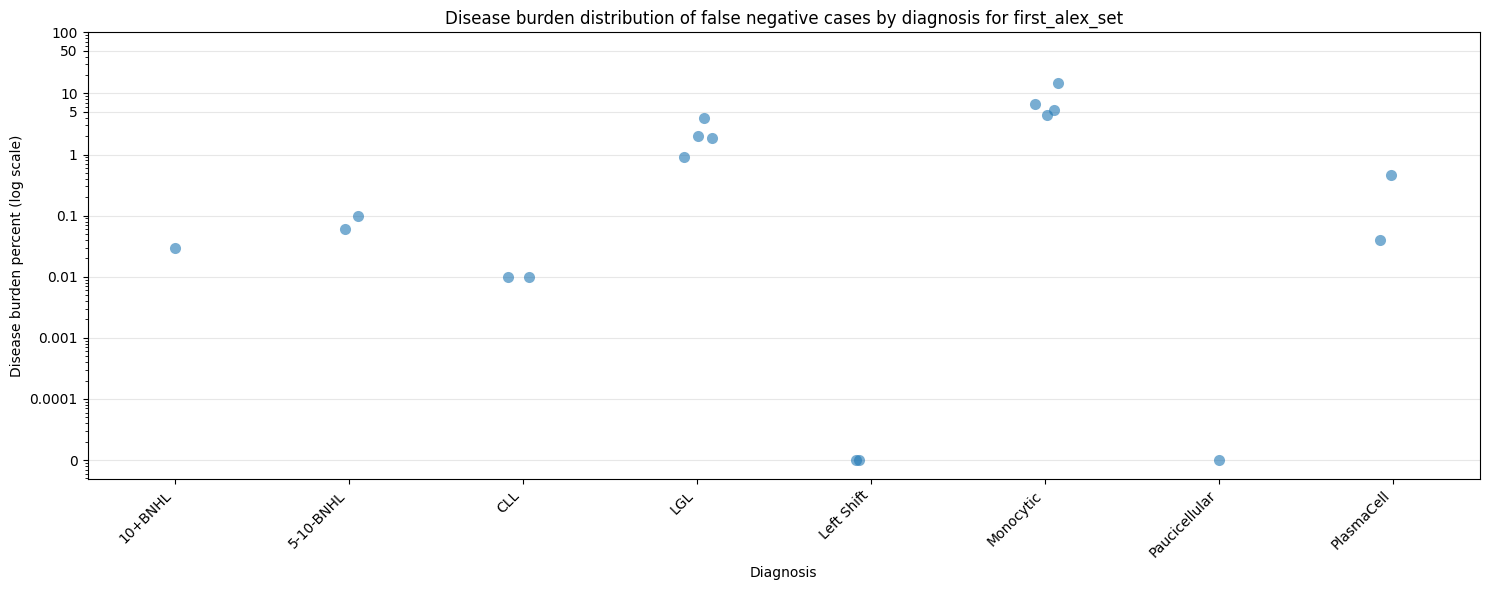


Performance Metrics (threshold=0.1)
TP: 3224, FN: 27, FP: 815, TN: 594
Recall:      0.992
Precision:   0.798
Specificity: 0.422
NPV:         0.957
F1:          0.884
ROC AUC:     0.981
     Category  Value
0         CLL   0.01
1         LGL   2.00
2   Monocytic  15.00
3   Monocytic   5.40
4  PlasmaCell   0.01


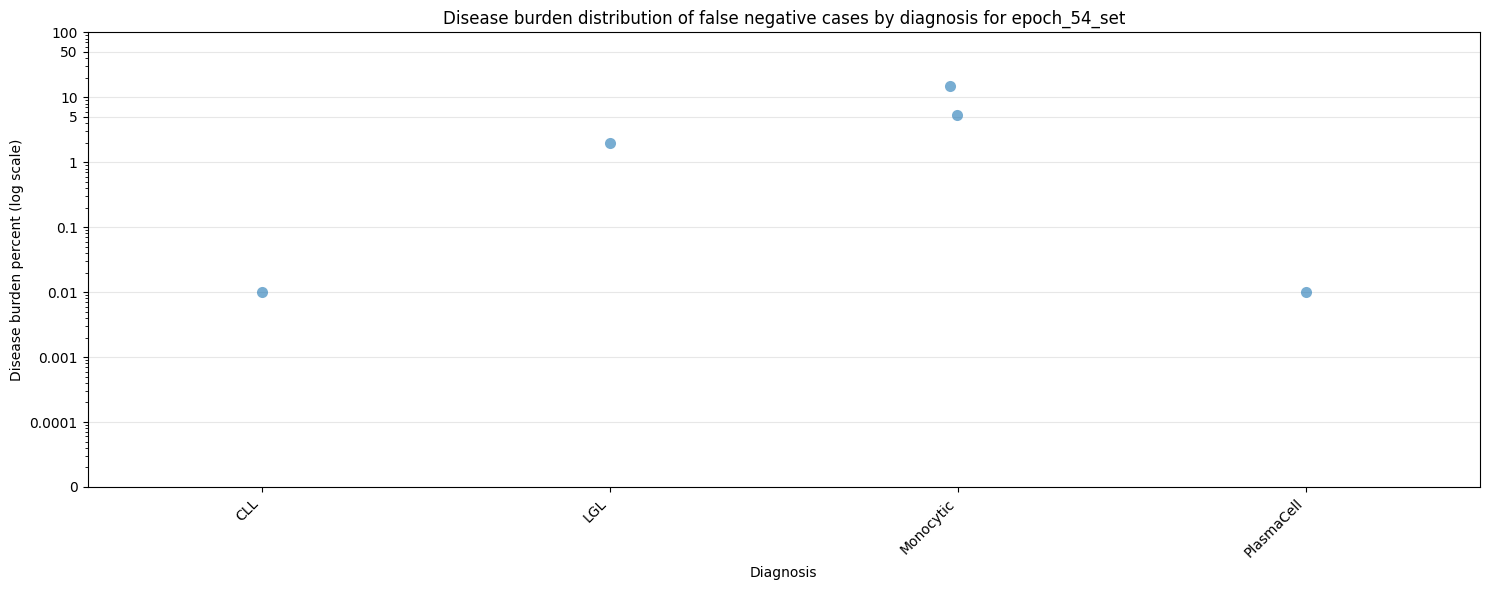


Performance Metrics (threshold=0.1)
TP: 3244, FN: 7, FP: 1063, TN: 346
Recall:      0.998
Precision:   0.753
Specificity: 0.246
NPV:         0.980
F1:          0.858
ROC AUC:     0.979
      Category     Value
0      10+BNHL   0.03000
1    5-10-BNHL   2.00000
2          CLL   0.01000
3          LGL   2.00000
4          LGL   4.00000
5   Left Shift   0.00001
6    Monocytic  15.00000
7    Monocytic   4.50000
8    Monocytic   5.40000
9    Monocytic   6.60000
10          NK   1.20000
11  PlasmaCell   0.04000
12  PlasmaCell   0.09000
13  PlasmaCell   0.02000
14  PlasmaCell   0.01000


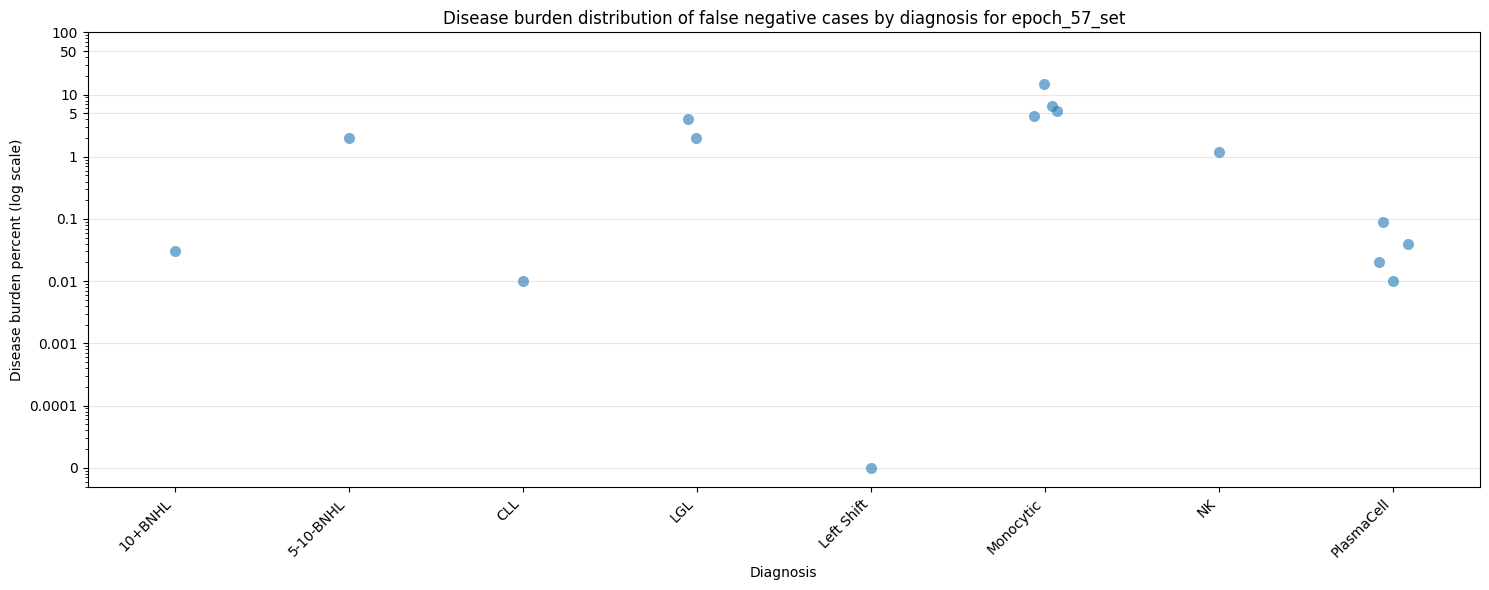


Performance Metrics (threshold=0.1)
TP: 3220, FN: 31, FP: 657, TN: 752
Recall:      0.990
Precision:   0.831
Specificity: 0.534
NPV:         0.960
F1:          0.903
ROC AUC:     0.981
         Category     Value
0         10+BNHL   0.03000
1       5-10-BNHL   2.00000
2             CLL   0.10000
3             CLL   0.01000
4             CLL   0.01000
5             LGL   1.90000
6             LGL   2.00000
7             LGL   4.00000
8      Left Shift   0.00001
9      Left Shift   0.00001
10      Monocytic  15.00000
11      Monocytic   4.50000
12      Monocytic   5.40000
13      Monocytic   4.00000
14      Monocytic   6.60000
15  Paucicellular   0.00001
16     PlasmaCell   0.04000
17     PlasmaCell   0.03000
18     PlasmaCell   0.46000
19     PlasmaCell   0.01000


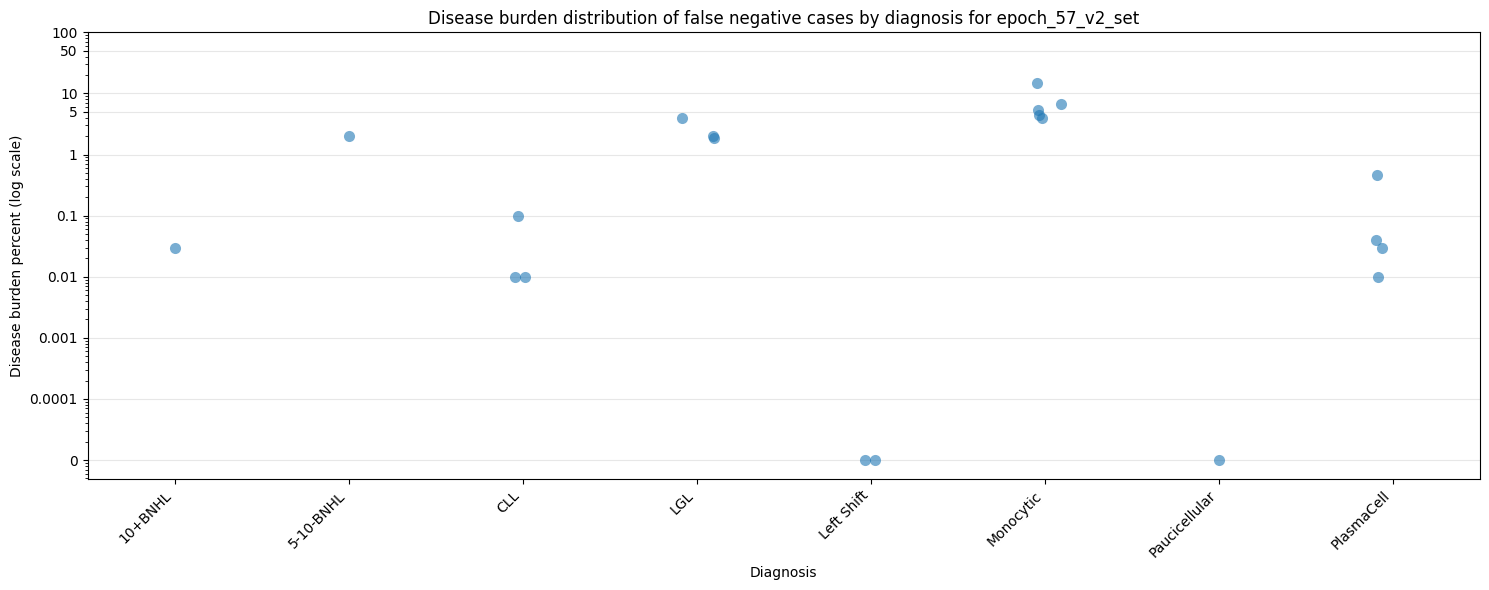


Performance Metrics (threshold=0.1)
TP: 3218, FN: 33, FP: 757, TN: 652
Recall:      0.990
Precision:   0.810
Specificity: 0.463
NPV:         0.952
F1:          0.891
ROC AUC:     0.980


{'threshold': 0.1,
 'tp': 3218,
 'fn': 33,
 'fp': 757,
 'tn': 652,
 'recall': 0.9898492771454936,
 'precision': 0.809559748427673,
 'specificity': 0.4627395315826828,
 'npv': 0.9518248175182482,
 'f1': 0.8906725712704124,
 'roc_auc': 0.9797190753557512}

In [10]:
plot_disease_burden(current_model_set, 'current_model_set')
compute_performance_metrics(current_model_set, threshold=0.1)
plot_disease_burden(first_alex_set, 'first_alex_set')
compute_performance_metrics(first_alex_set, threshold=0.1)
plot_disease_burden(epoch_54_set, 'epoch_54_set')
compute_performance_metrics(epoch_54_set, threshold=0.1)
plot_disease_burden(epoch_57_set, 'epoch_57_set')
compute_performance_metrics(epoch_57_set, threshold=0.1)
plot_disease_burden(epoch_57_v2_set, 'epoch_57_v2_set')
compute_performance_metrics(epoch_57_v2_set, threshold=0.1)

         Category     Value
0         10+BNHL   0.03000
1          5+BNHL   0.20000
2       5-10-BNHL   0.06000
3       5-10-BNHL   0.10000
4       5-10-BNHL   0.50000
5       5-10-BNHL   2.00000
6       5-10-BNHL   0.07400
7       5-10-BNHL   0.40000
8       5-10-BNHL   0.20000
9       5-10-BNHL   0.20000
10            CLL   0.02000
11            CLL   0.06000
12            CLL   0.10000
13            CLL   0.01000
14            CLL   0.01000
15            CLL   0.00001
16            LGL   1.90000
17            LGL   0.90000
18            LGL   2.00000
19            LGL   2.00000
20            LGL   5.50000
21     Left Shift   0.00001
22     Left Shift   0.00001
23     Left Shift   0.00001
24     Left Shift   0.00001
25     Left Shift   0.00001
26     Left Shift   0.00001
27      Monocytic  24.00000
28      Monocytic  15.00000
29      Monocytic   6.30000
30      Monocytic   4.50000
31      Monocytic   5.40000
32      Monocytic   5.20000
33      Monocytic   5.00000
34      Monocytic  2

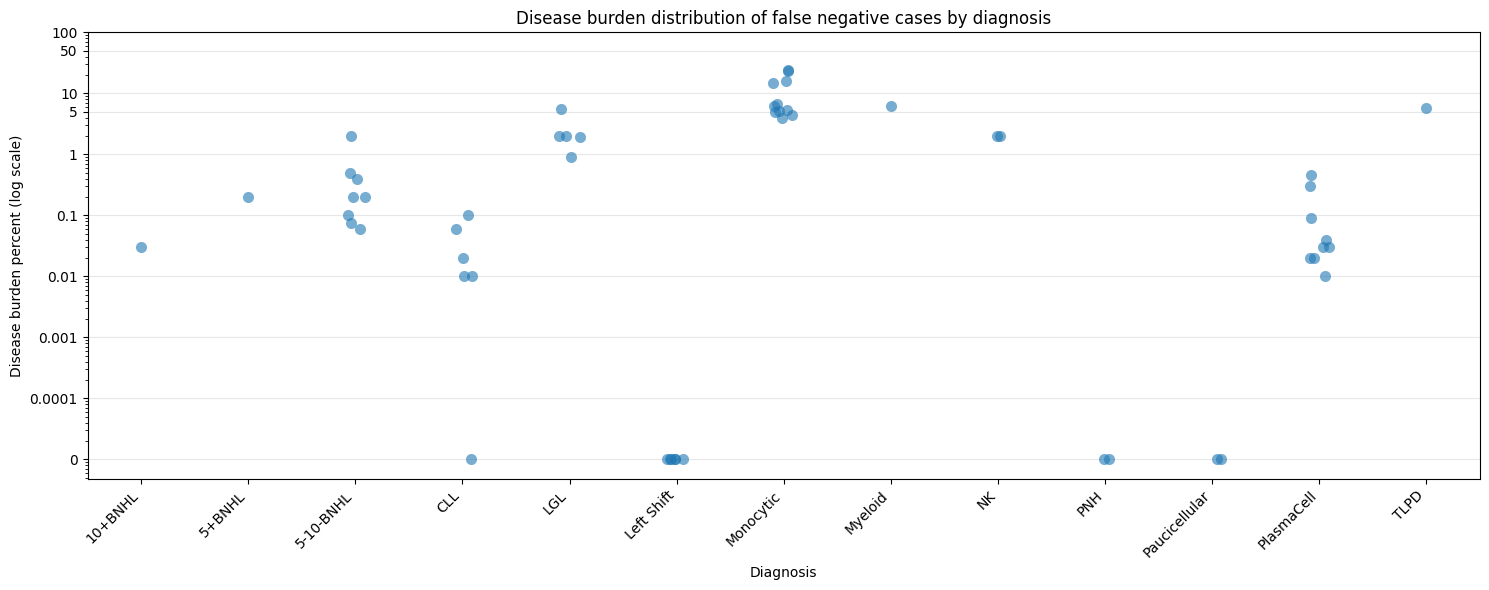

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data_dict = {
    # ... your dictionary
}

# Convert to DataFrame
data_list = []
for key, values in dictio_disease_burden.items():
    if key=='Weak33' or key=='CLL_Class' or key=='Suboptimal' or key=='ADD_ON' or key=='CLL_Class':
        continue
    for value in values:
        if key=='Left Shift' and value!=0:
            value=0
        if value==0:
            value+=0.00001
        data_list.append({'Category': key, 'Value': value})

df = pd.DataFrame(data_list)

print(df)

# Create plot
fig, ax = plt.subplots(figsize=(15, 6))
sns.stripplot(data=df, x='Category', y='Value', alpha=0.6, size=8, ax=ax)
ax.set_xlabel('Diagnosis')
ax.set_ylabel('Disease burden percent (log scale)')
ax.set_title("Disease burden distribution of false negative cases by diagnosis")
ax.set_yscale('log')  # This makes the y-axis logarithmic

# Set custom y-axis ticks
custom_ticks = [1e-5, 0.0001, 0.001, 0.01, 0.1, 1, 5, 10, 50, 100]
ax.set_yticks(custom_ticks)
ax.set_yticklabels(['0','0.0001', '0.001', '0.01', '0.1', '1', '5', '10', '50', '100'])

# Note: 0 cannot be displayed on a log scale, so it's excluded from the ticks

plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [13]:
clasi=['10+BNHL', '5+BNHL', '5-10-BNHL',
'AML', 'BALL', 'CLL', 'Clotted', 'Eos',
'HCL',  'Hemodilute', 'High48Ratio', 'LGL',
'Left Shift', 'MastCell', 'Monocytic', 'Myeloid', 'NK', 'No20', 
'PNH', 'Paucicellular', 'PlasmaCell', 'Reversed48Ratio', 'Sezary',
'Suboptimal', 'TALL', 'TLPD', 'Weak33']

dictio_disease_burden={}
for cl in clasi:
    dictio_disease_burden[cl]=epoch_54_set[(epoch_54_set['FINAL_NORMAL']==True) & (epoch_54_set['mean_probability']<0.2) & (epoch_54_set['disease_burden']>=0) & (epoch_54_set['predicted_value']>85) & (epoch_54_set[cl]==True)][['10+BNHL', '5+BNHL', '5-10-BNHL',
       'AML', 'BALL', 'CLL', 'Clotted', 'Eos',
        'HCL',  'Hemodilute', 'High48Ratio', 'LGL',
       'Left Shift', 'MastCell', 'Monocytic', 'Myeloid', 'NK', 'No20', 
       'PNH', 'Paucicellular', 'PlasmaCell', 'Reversed48Ratio', 'Sezary',
       'Suboptimal', 'TALL', 'TLPD', 'Weak33', 'disease_burden', 'chart_text_x','ACCESSION_x']]['disease_burden'].tolist()


         Category     Value
0         10+BNHL   0.03000
1          5+BNHL   0.20000
2       5-10-BNHL   0.06000
3       5-10-BNHL   1.50000
4       5-10-BNHL   0.10000
5       5-10-BNHL   0.20000
6             CLL   0.08000
7             CLL   0.01000
8             CLL   0.01000
9             LGL   1.90000
10            LGL   0.90000
11            LGL   2.00000
12            LGL   4.00000
13     Left Shift   0.00001
14     Left Shift   0.00001
15     Left Shift   0.00001
16      Monocytic  15.00000
17      Monocytic   4.50000
18      Monocytic   5.40000
19      Monocytic   5.00000
20      Monocytic   4.00000
21      Monocytic  21.00000
22      Monocytic  16.00000
23      Monocytic   6.60000
24  Paucicellular   0.00001
25     PlasmaCell   0.04000
26     PlasmaCell   0.02000
27     PlasmaCell   0.03000
28     PlasmaCell   0.09000
29     PlasmaCell   0.01000
30     PlasmaCell   0.03000
31           TLPD   3.70000


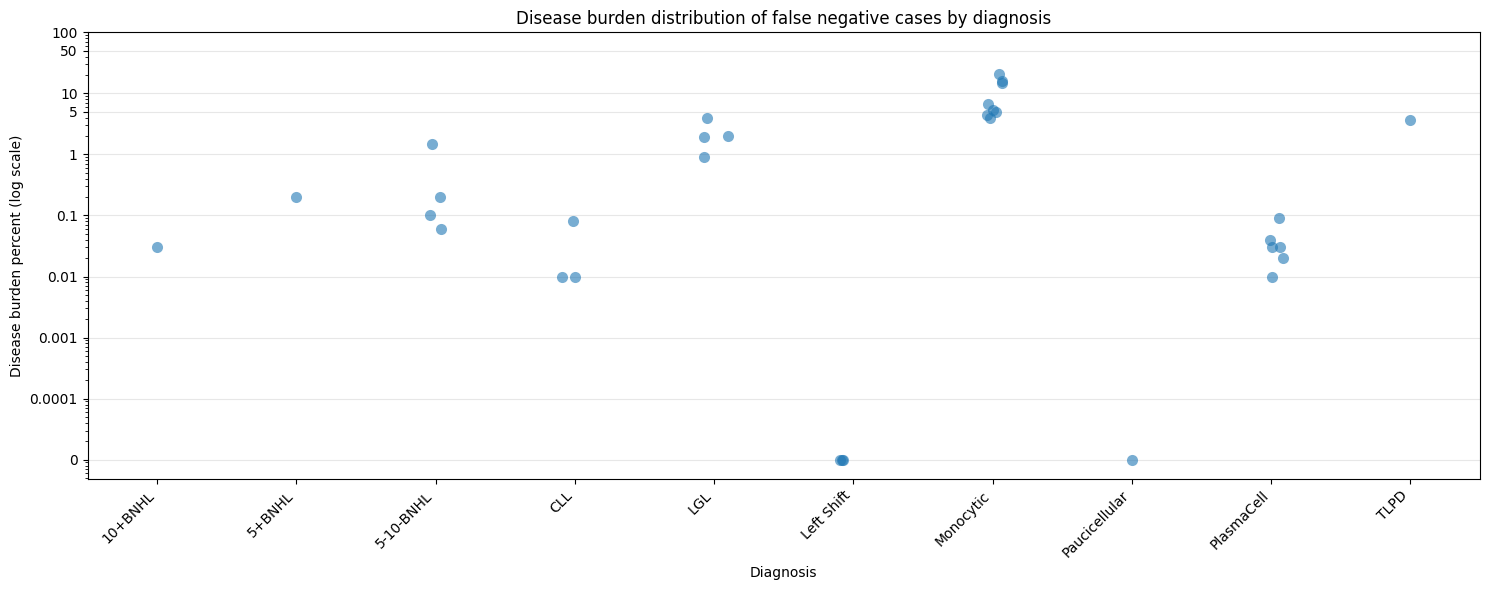

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data_dict = {
    # ... your dictionary
}

# Convert to DataFrame
data_list = []
for key, values in dictio_disease_burden.items():
    if key=='Weak33' or key=='CLL_Class' or key=='Suboptimal' or key=='ADD_ON' or key=='CLL_Class':
        continue
    for value in values:
        if key=='Left Shift' and value!=0:
            value=0
        if value==0:
            value+=0.00001
        data_list.append({'Category': key, 'Value': value})

df = pd.DataFrame(data_list)

print(df)

# Create plot
fig, ax = plt.subplots(figsize=(15, 6))
sns.stripplot(data=df, x='Category', y='Value', alpha=0.6, size=8, ax=ax)
ax.set_xlabel('Diagnosis')
ax.set_ylabel('Disease burden percent (log scale)')
ax.set_title("Disease burden distribution of false negative cases by diagnosis")
ax.set_yscale('log')  # This makes the y-axis logarithmic

# Set custom y-axis ticks
custom_ticks = [1e-5, 0.0001, 0.001, 0.01, 0.1, 1, 5, 10, 50, 100]
ax.set_yticks(custom_ticks)
ax.set_yticklabels(['0','0.0001', '0.001', '0.01', '0.1', '1', '5', '10', '50', '100'])

# Note: 0 cannot be displayed on a log scale, so it's excluded from the ticks

plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [17]:
compute_performance_metrics(current_model_set, threshold=0.2)


Performance Metrics (threshold=0.2)
TP: 3175, FN: 76, FP: 361, TN: 1048
Recall:      0.977
Precision:   0.898
Specificity: 0.744
NPV:         0.932
F1:          0.936
ROC AUC:     0.982


{'threshold': 0.2,
 'tp': 3175,
 'fn': 76,
 'fp': 361,
 'tn': 1048,
 'recall': 0.9766225776684098,
 'precision': 0.8979072398190046,
 'specificity': 0.7437899219304471,
 'npv': 0.9323843416370107,
 'f1': 0.9356121997937233,
 'roc_auc': 0.981952487622414}

In [18]:
compute_performance_metrics(epoch_54_set, threshold=0.2)


Performance Metrics (threshold=0.2)
TP: 3195, FN: 56, FP: 532, TN: 877
Recall:      0.983
Precision:   0.857
Specificity: 0.622
NPV:         0.940
F1:          0.916
ROC AUC:     0.979


{'threshold': 0.2,
 'tp': 3195,
 'fn': 56,
 'fp': 532,
 'tn': 877,
 'recall': 0.982774530913565,
 'precision': 0.8572578481352294,
 'specificity': 0.6224272533711852,
 'npv': 0.939978563772776,
 'f1': 0.9157351676698194,
 'roc_auc': 0.9792612809641582}

In [3]:
compute_performance_metrics(test_set, threshold=0.1)


Performance Metrics (threshold=0.1)
TP: 3221, FN: 30, FP: 676, TN: 733
Recall:      0.991
Precision:   0.827
Specificity: 0.520
NPV:         0.961
F1:          0.901
ROC AUC:     0.982


{'threshold': 0.1,
 'tp': 3221,
 'fn': 30,
 'fp': 676,
 'tn': 733,
 'recall': 0.990772070132267,
 'precision': 0.8265332306902746,
 'specificity': 0.5202271114265437,
 'npv': 0.9606815203145478,
 'f1': 0.9012311135982093,
 'roc_auc': 0.981952487622414}

In [4]:
test_set

,ACCESSION_x,sample_type,NORMAL,10+BNHL,5+BNHL,5-10-BNHL,AML,B-NHL,BALL,CLL,...,ACCESSION_y,tube_type,raw_logit,predicted_value,extracted_ACCESSION,viab_GT_80,gold_viab_GT_80,FINAL_NORMAL,FINAL_PREDICTED_NORMAL,FINAL_MODEL_SCORE
0,24355123439,PERIPHERAL BLOOD,True,False,False,False,False,False,False,False,...,tensor(24355123439),b,1.598706,83.183754,24355123439,True,True,True,True,1.000000
1,24355124784,PERIPHERAL BLOOD,True,False,False,False,False,False,False,False,...,tensor(24355124784),b,2.115179,89.236969,24355124784,True,True,False,False,0.061279
2,24355128607,PERIPHERAL BLOOD,False,False,False,False,False,False,False,True,...,tensor(24355128607),b,2.803180,94.284744,24355128607,True,True,True,True,1.000000
3,24355129003,PERIPHERAL BLOOD,False,False,True,True,False,False,False,True,...,tensor(24355129003),b,2.422192,91.850388,24355129003,True,True,True,True,1.000000
4,24355129400,PERIPHERAL BLOOD,True,False,False,False,False,False,False,False,...,tensor(24355129400),b,2.493009,92.365021,24355129400,True,True,False,True,0.166992
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4997,25139117438,PERIPHERAL BLOOD,False,False,False,False,False,False,False,False,...,tensor(25139117438),b,2.031306,88.404503,25139117438,True,True,True,True,0.980469
4998,25139119133,PERIPHERAL BLOOD,True,False,False,False,False,False,False,False,...,tensor(25139119133),b,2.203897,90.059891,25139119133,True,True,False,False,0.072917
4999,25139122702,PERIPHERAL BLOOD,True,False,False,False,False,False,False,False,...,tensor(25139122702),b,1.579734,82.916679,25139122702,True,False,True,True,1.000000
5000,25139122783,PERIPHERAL BLOOD,False,False,False,False,False,False,False,False,...,tensor(25139122783),b,1.378589,79.876427,25139122783,False,False,True,True,1.000000


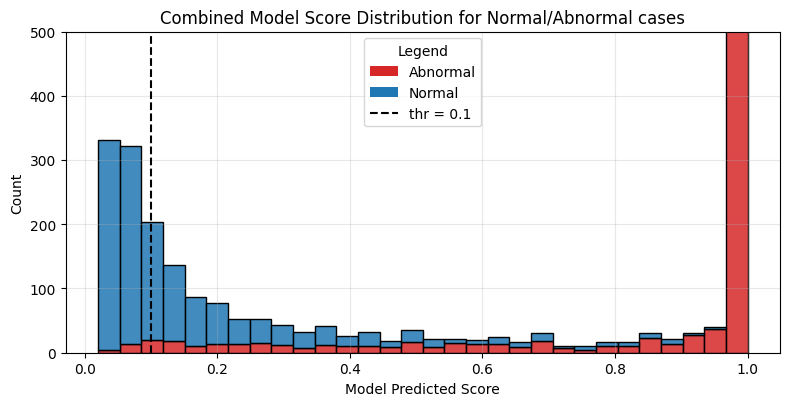

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

palette = {True: 'tab:red', False: 'tab:blue'}

plt.figure(figsize=(8, 4))
ax = sns.histplot(
    data=test_set,
    x='FINAL_MODEL_SCORE',
    hue='FINAL_NORMAL',
    palette=palette,
    bins=30,
    multiple='stack',
    alpha=0.85,
    legend=False   # suppress auto legend
)

line = ax.axvline(0.1, color='k', linestyle='--', linewidth=1.5)

legend_handles = [
    Patch(facecolor=palette[True], label='Abnormal'),
    Patch(facecolor=palette[False], label='Normal'),
    Line2D([00], [0], color='k', linestyle='--', label='thr = 0.1')
]

ax.legend(handles=legend_handles, title='Legend', loc='upper center')
ax.grid(True, alpha=0.3)  # Add this line
ax.set_ylim(0, 500) 
plt.xlabel("Model Predicted Score")
plt.ylabel('Count')
plt.tight_layout()
plt.title('Combined Model Score Distribution for Normal/Abnormal cases')
plt.show()

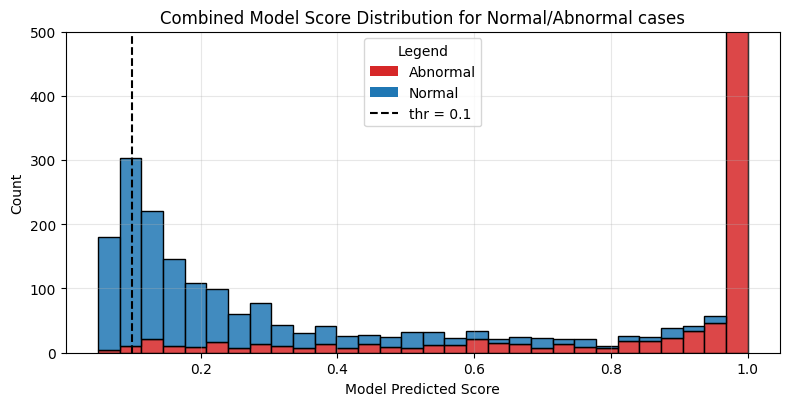

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

palette = {True: 'tab:red', False: 'tab:blue'}

plt.figure(figsize=(8, 4))
ax = sns.histplot(
    data=test_set,
    x='FINAL_MODEL_SCORE',
    hue='FINAL_NORMAL',
    palette=palette,
    bins=30,
    multiple='stack',
    alpha=0.85,
    legend=False   # suppress auto legend
)

line = ax.axvline(0.1, color='k', linestyle='--', linewidth=1.5)

legend_handles = [
    Patch(facecolor=palette[True], label='Abnormal'),
    Patch(facecolor=palette[False], label='Normal'),
    Line2D([00], [0], color='k', linestyle='--', label='thr = 0.1')
]

ax.legend(handles=legend_handles, title='Legend', loc='upper center')
ax.grid(True, alpha=0.3)  # Add this line
ax.set_ylim(0, 500) 
plt.xlabel("Model Predicted Score")
plt.ylabel('Count')
plt.tight_layout()
plt.title('Combined Model Score Distribution for Normal/Abnormal cases')
plt.show()

In [11]:
compute_performance_metrics(test_set, threshold=0.16)


Performance Metrics (threshold=0.16)
TP: 3211, FN: 40, FP: 676, TN: 733
Recall:      0.988
Precision:   0.826
Specificity: 0.520
NPV:         0.948
F1:          0.900
ROC AUC:     0.979


{'threshold': 0.16,
 'tp': 3211,
 'fn': 40,
 'fp': 676,
 'tn': 733,
 'recall': 0.9876960935096893,
 'precision': 0.8260869565217391,
 'specificity': 0.5202271114265437,
 'npv': 0.9482535575679172,
 'f1': 0.8996917904174839,
 'roc_auc': 0.9792612809641582}

In [2]:
new_train=pd.read_csv('/home/32210/test_things/lmd_conversion/updated_train_set_09052025_withreports.csv')
new_test=pd.read_csv('/home/32210/test_things/lmd_conversion/updated_test_set_09052025_withreports.csv')
new_train_pb=pd.read_csv('/home/32210/test_things/lmd_conversion/updated_train_set_09052025_pb.csv')
new_test_pb=pd.read_csv('/home/32210/test_things/lmd_conversion/updated_test_set_09052025_pb.csv')

In [3]:
import re

def is_test_case(filename):
    """
    Detect if a filename is a test case based on specific patterns.
    Returns True if it's a test case, False otherwise.
    """
    # Define test patterns that should be detected
    test_patterns = [
        r'^arup\s+TEST\b',      # 'arup TEST' at start
        r'^ARUPTEST\b',         # 'ARUPTEST' at start  
        r'^SS\s+TEST\b',        # 'SS TEST' at start
        r'^ZZTEST\b',           # 'ZZTEST' at start
        r'^TEST\s+\d+',         # 'TEST' followed by numbers (like TEST 25112100994)
    ]
    
    # Check if filename matches any test pattern
    for pattern in test_patterns:
        if re.search(pattern, filename, re.IGNORECASE):
            return True
    
    return False

list_of_test_set_accessions=[]

for idx, row in new_test.iterrows():
    list_of_strings = ast.literal_eval(row['fil'])
    leni=len(list_of_strings)
    counti=0
    for el in list_of_strings:
        if is_test_case(el):
            counti+=1
    if counti==leni:
        print(row['ACCESSION'])
        print(row['fil'])
        list_of_test_set_accessions.append(row['ACCESSION'])

new_test=new_test[~new_test['ACCESSION'].isin(list_of_test_set_accessions)]
len(new_test)
#9993


25021115448
['ARUPTEST 25021115448 00117798 002.LMD', 'ARUPTEST 25021115448 00117797 001.LMD', 'ARUPTEST 25021115448 00117799 003.LMD']
25063101267
['ARUPTEST 25063101267 00046549 003.LMD', 'ARUPTEST 25063101267 00046547 001.LMD', 'ARUPTEST 25063101267 00046548 002.LMD']
25091122528
['aruptest 17163 25091122528 00091839 001.LMD', 'aruptest 17163 25091122528 00091840 002.LMD', 'aruptest 17163 25091122528 00091841 003.LMD']
25111111605
['ARUPTEST BM NORMAL 25111111605 00119660 002.LMD', 'ARUPTEST BM NORMAL 25111111605 00119661 003.LMD', 'ARUPTEST BM NORMAL 25111111605 00119659 001.LMD']
25112100994
['TEST 25112100994 00000678 671.LMD', 'TEST 25112100994 00000677 670.LMD', 'TEST 25112100994 00000679 672.LMD']
25126101258
['ARUPTEST 17109 25126101258 00051278 003.LMD', 'ARUPTEST 17109 25126101258 00051276 001.LMD', 'ARUPTEST 17109 25126101258 00051277 002.LMD']
25183102501
['ARUPTEST 25183102501 00108899 001.LMD', 'ARUPTEST 25183102501 00108900 002.LMD', 'ARUPTEST 25183102501 00108901 003.

9993

In [4]:
count_bm=0
count_pb=0


pattern_bm = r'(SAMPLE|SPECIMEN)\s*:\s*BONE\s+MARROW'
pattern_pb = r'(SAMPLE|SPECIMEN)\s*:\s*PERIPHERAL\s+BLOOD'



for idx, row in new_test.iterrows():
    
    if re.search(pattern_bm, row['chart_text'], re.IGNORECASE):
        count_bm+=1
 
    elif re.search(pattern_pb, row['chart_text'], re.IGNORECASE):
        count_pb+=1
    else:
        print(row['chart_text'])
    
       


        
print(count_bm)
print(count_pb)


pattern_bm = r'(SAMPLE|SPECIMEN)\s*:\s*BONE\s+MARROW'
pattern_pb = r'(SAMPLE|SPECIMEN)\s*:\s*PERIPHERAL\s+BLOOD'


error_pb=[]
error_bm=[]
for idx, row in new_test.iterrows():
    
    if re.search(pattern_bm, row['chart_text'], re.IGNORECASE) and row['sample_type']=='PERIPHERAL BLOOD':
        error_pb.append(row['ACCESSION'])
    if re.search(pattern_pb, row['chart_text'], re.IGNORECASE) and row['sample_type']=='BONE MARROW':
        error_bm.append(row['ACCESSION'])


print(len(new_test))
print(len(error_pb))
print(len(error_bm))
# 2038
# 7955
# 9993
# 956
# 15

2038
7955
9993
956
15


In [5]:
# Update single condition
for ac in error_pb:
    new_test.loc[new_test['ACCESSION'] == ac, 'sample_type'] = 'BONE MARROW'
for ac in error_bm:
    new_test.loc[new_test['ACCESSION'] == ac, 'sample_type'] = 'PERIPHERAL BLOOD'

len(new_test)

9993

In [6]:
results=pd.read_csv('/home/32210/git/dinoflow/scripts/my_evaluation_oct2325_predictions.csv')
#results=pd.read_csv('/home/32210/git/dinoflow/scripts/contrast_eval_results_epoch54_predictions.csv')


In [7]:
new_test_with_preds=new_test.merge(results, left_on='ACCESSION', right_on='accession', how='left')
new_test_with_preds=new_test_with_preds[new_test_with_preds['sample_type']=='PERIPHERAL BLOOD'].copy()
ollama_results_test=pd.read_csv('/home/32210/test_things/lmd_conversion/results_ollama_test.csv')

In [8]:
import pandas as pd
import json
import re

# Function to extract values from the Result column
def extract_json_values(result_string):
    """
    Extract disease_burden_pct and viability_pct from the Result column
    """
    try:
        # Use regex to find the JSON content between <final> tags
        match = re.search(r'<final>(.*?)</final>', result_string, re.DOTALL)
        if match:
            json_str = match.group(1).strip()
            # Parse the JSON
            data = json.loads(json_str)
            return data.get('disease_burden_pct'), data.get('viability_pct')
        else:
            return None, None
    except (json.JSONDecodeError, AttributeError, TypeError):
        return None, None

# Apply the function to create new columns
def add_disease_burden_viability_columns(df):
    """
    Add disease_burden and viability columns to the dataframe
    """
    # Extract values from Result column
    extracted_values = df['Result'].apply(extract_json_values)
    
    # Create new columns
    df['disease_burden'] = extracted_values.apply(lambda x: x[0])
    df['viability'] = extracted_values.apply(lambda x: x[1])
    
    return df

# Example usage:
# df = pd.read_csv('your_file.csv')
# df = add_disease_burden_viability_columns(df)

# Or if you want to do it step by step:
# df[['disease_burden', 'viability']] = df['Result'].apply(extract_json_values).apply(pd.Series)
# Extract disease_burden and viability from Result column
ollama_results_test[['disease_burden', 'viability']] = ollama_results_test['Result'].apply(
    lambda x: pd.Series(extract_json_values(x))
)

new_test_with_preds=new_test_with_preds.merge(ollama_results_test, left_on='ACCESSION', right_on='ACCESSION', how='left').copy()
new_test_with_preds=new_test_with_preds[~new_test_with_preds['accession'].isna()].copy()

viability_model_results=pd.read_csv('/home/32210/git/dinoflow/predictions_20251023_164239.csv')

viability_model_results['extracted_ACCESSION'] = viability_model_results['ACCESSION'].str.extract(r'\((\d+)\)').astype(int)

new_test_with_preds=new_test_with_preds[new_test_with_preds['sample_type']=='PERIPHERAL BLOOD'].copy()

new_test_with_preds=new_test_with_preds.merge(viability_model_results, left_on='ACCESSION', right_on='extracted_ACCESSION', how='left').copy()

new_test_with_preds=new_test_with_preds[new_test_with_preds['viability'].notna()].copy()

new_test_with_preds['viab_GT_80'] = new_test_with_preds['predicted_value'] > 80
new_test_with_preds['gold_viab_GT_80'] = new_test_with_preds['viability'] > 80

In [9]:
new_test_with_preds=new_test_with_preds.iloc[0:5000].copy()
len(new_test_with_preds)

5000

In [10]:
import numpy as np
import pandas as pd
from sklearn.metrics import (f1_score, precision_score, recall_score, 
                           roc_curve, precision_recall_curve, auc,
                           confusion_matrix)
import matplotlib.pyplot as plt

def evaluate_model_comprehensive(df, th, prob_col='mean_prob', true_label_col='true_label'):
    """
    Comprehensive model evaluation with sensitivity-constrained thresholds
    
    Parameters:
    - df: DataFrame with predictions and true labels
    - prob_col: column name with predicted probabilities
    - true_label_col: column name with true labels
    """
    
    print(f"Evaluating {len(df)} samples")
    
    y_true = df[true_label_col].astype(int)
    y_prob = df[prob_col]
    
    # Standard F1 score at threshold 
    y_pred_th = (y_prob >= th).astype(int)
    f1_th = f1_score(y_true, y_pred_th)
    recall_th = recall_score(y_true, y_pred_th)
    precision_th = precision_score(y_true, y_pred_th)
    
    print(f"F1 score at threshold {th}: {f1_th:.4f}")
    print(f"Recall at threshold {th}: {recall_th:.4f}")
    print(f"Precision at threshold {th}: {precision_th:.4f}")
    
    # Get confusion matrix for threshold 0.5
    tn_th, fp_th, fn_th, tp_th = confusion_matrix(y_true, y_pred_th).ravel()
    print(f"TP={tp_th}, FP={fp_th}, FN={fn_th}, TN={tn_th}")
    print("Specificity: ", tn_th/(tn_th+fp_th))
    
    # Compute ROC curve
    fpr, tpr, thresholds_roc = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.4f}")
    
    # Compute PR curve  
    precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall_vals, precision_vals)
    print(f"PR AUC: {pr_auc:.4f}")
    
    # Define sensitivity thresholds
    sensitivity_thresholds = [0.99]
    
    # Store results for each sensitivity threshold
    sensitivity_results = []
    
    # Compute specificity at each sensitivity threshold (following your example)
    for sens_threshold in sensitivity_thresholds:
        print(f"\n--- Metrics at {sens_threshold*100}% Sensitivity ---")
        
        # Find indices where TPR (sensitivity) >= threshold
        idx = tpr >= sens_threshold
        specificity_vals = 1 - fpr[idx]  # Convert FPR to specificity
        
        if len(specificity_vals) > 0:
            # Get the maximum specificity (minimum FPR) at this sensitivity level
            max_specificity = max(specificity_vals)
            best_idx = np.where((tpr >= sens_threshold) & ((1 - fpr) == max_specificity))[0][0]
            
            threshold = thresholds_roc[best_idx]
            actual_sensitivity = tpr[best_idx]
            actual_specificity = 1 - fpr[best_idx]

            # print(f"Threshold: {threshold}")
            # print(f"Actual Sensitivity: {actual_sensitivity:.4f}")
            print(f"Threshold: {threshold:.4f}")
            print(f"Actual Sensitivity: {actual_sensitivity:.4f}")
            print(f"Actual Specificity: {actual_specificity:.4f}")
            
            # Get predictions at this threshold
            y_pred_thresh = (y_prob >= threshold).astype(int)
            
            # Compute confusion matrix
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred_thresh).ravel()
            
            # Calculate PPV and NPV
            ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Positive Predictive Value
            npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Negative Predictive Value
            
            print(f"PPV (Precision): {ppv:.4f}")
            print(f"NPV: {npv:.4f}")
            print(f"TP={tp}, FP={fp}, FN={fn}, TN={tn}")
            
            # Store results
            sensitivity_results.append({
                'target_sensitivity': sens_threshold,
                'threshold': threshold,
                'actual_sensitivity': actual_sensitivity,
                'specificity': actual_specificity,
                'ppv': ppv,
                'npv': npv,
                'confusion_matrix': {'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn}
            })
            
        else:
            print(f"No threshold achieves {sens_threshold*100}% sensitivity")
            sensitivity_results.append({
                'target_sensitivity': sens_threshold,
                'threshold': 0.0,
                'actual_sensitivity': 1.0,
                'specificity': 0.0,
                'ppv': 0.0,
                'npv': 0.0,
                'confusion_matrix': {'TP': 0, 'FP': 0, 'FN': 0, 'TN': 0}
            })
    
    # Return comprehensive results
    return {
        'overall_metrics': {
            'f1_score_at_th': f1_th,
            'recall_at_th': recall_th,
            'precision_at_th': precision_th,
            'roc_auc': roc_auc,
            'pr_auc': pr_auc,
            'confusion_matrix_th': {'TP': tp_th, 'FP': fp_th, 'FN': fn_th, 'TN': tn_th}
        },
        'sensitivity_constrained': sensitivity_results,
        'curves': {
            'roc': {'fpr': fpr, 'tpr': tpr, 'thresholds': thresholds_roc},
            'pr': {'precision': precision_vals, 'recall': recall_vals, 'thresholds': pr_thresholds}
        }
    }

# def plot_evaluation_curves(results, figsize=(15, 5)):
#     """Plot ROC and PR curves with sensitivity thresholds marked"""
    
#     fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=figsize)
    
#     # ROC Curve
#     roc_data = results['curves']['roc']
#     ax1.plot(roc_data['fpr'], roc_data['tpr'], 'b-', 
#              label=f'ROC (AUC = {results["overall_metrics"]["roc_auc"]:.3f})')
#     ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    
#     # Mark sensitivity thresholds on ROC curve
#     for result in results['sensitivity_constrained']:
#         sens = result['actual_sensitivity']
#         spec = result['specificity']
#         fpr_point = 1 - spec
#         ax1.plot(fpr_point, sens, 'ro', markersize=8, 
#                 label=f'{result["target_sensitivity"]*100}% Sens')
    
#     ax1.set_xlabel('False Positive Rate')
#     ax1.set_ylabel('Sensitivity')
#     ax1.set_title('ROC Curve')
#     ax1.legend()
#     ax1.grid(True, alpha=0.3)
    
#     # PR Curve
#     pr_data = results['curves']['pr']
#     ax2.plot(pr_data['recall'], pr_data['precision'], 'r-',
#              label=f'PR (AUC = {results["overall_metrics"]["pr_auc"]:.3f})')
    
#     # Mark sensitivity thresholds on PR curve
#     for result in results['sensitivity_constrained']:
#         sens = result['actual_sensitivity']
#         ppv = result['ppv']
#         ax2.plot(sens, ppv, 'go', markersize=8,
#                 label=f'{result["target_sensitivity"]*100}% Sens (PPV={ppv:.3f})')
    
#     ax2.set_xlabel('Recall (Sensitivity)')
#     ax2.set_ylabel('Precision')
#     ax2.set_title('Precision-Recall Curve')
#     ax2.legend()
#     ax2.grid(True, alpha=0.3)
    
#     # Metrics summary plot
#     sens_targets = [r['target_sensitivity']*100 for r in results['sensitivity_constrained']]
#     specificities = [r['specificity']*100 for r in results['sensitivity_constrained']]
#     ppvs = [r['ppv']*100 for r in results['sensitivity_constrained']]
#     npvs = [r['npv']*100 for r in results['sensitivity_constrained']]
    
#     x = np.arange(len(sens_targets))
#     width = 0.25
    
#     ax3.bar(x - width, specificities, width, label='Specificity', alpha=0.8)
#     ax3.bar(x, ppvs, width, label='PPV', alpha=0.8)
#     ax3.bar(x + width, npvs, width, label='NPV', alpha=0.8)
    
#     ax3.set_xlabel('Sensitivity Target (%)')
#     ax3.set_ylabel('Metric Value (%)')
#     ax3.set_title('Metrics at Different Sensitivity Thresholds')
#     ax3.set_xticks(x)
#     ax3.set_xticklabels([f'{s}%' for s in sens_targets])
#     ax3.legend()
#     ax3.grid(True, alpha=0.3)
    
#     plt.tight_layout()
#     plt.show()

def plot_evaluation_curves(results, figsize=(12, 5), title_name='ROC Curve'):
    """Plot ROC and PR curves with sensitivity thresholds marked"""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # ROC Curve
    roc_data = results['curves']['roc']
    ax1.plot(roc_data['fpr'], roc_data['tpr'], 'b-',
             label=f'ROC (AUC = {results["overall_metrics"]["roc_auc"]:.3f})')
    ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)

    for result in results['sensitivity_constrained']:
        sens = result['actual_sensitivity']
        spec = result['specificity']
        fpr_point = 1 - spec
        ax1.plot(fpr_point, sens, 'ro', markersize=8,
                 label=f'{result["target_sensitivity"]*100}% Sens')

    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('Sensitivity')
    ax1.set_title(title_name)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # PR Curve
    pr_data = results['curves']['pr']
    ax2.plot(pr_data['recall'], pr_data['precision'], 'r-',
             label=f'PR (AUC = {results["overall_metrics"]["pr_auc"]:.3f})')

    for result in results['sensitivity_constrained']:
        sens = result['actual_sensitivity']
        ppv = result['ppv']
        ax2.plot(sens, ppv, 'go', markersize=8,
                 label=f'{result["target_sensitivity"]*100}% Sens (PPV={ppv:.3f})')

    ax2.set_xlabel('Recall (Sensitivity)')
    ax2.set_ylabel('Precision')
    ax2.set_title('Precision-Recall Curve')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_curves_with_threshold_annotations(results, num_points=10, figsize=(12, 5)):
    """Plot ROC/PR curves and annotate selected points with their thresholds."""

    roc = results['curves']['roc']
    pr = results['curves']['pr']

    fpr, tpr, thr_roc = roc['fpr'], roc['tpr'], roc['thresholds']
    precision, recall, thr_pr = pr['precision'], pr['recall'], pr['thresholds']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # ROC curve
    ax1.plot(fpr, tpr, 'b-', alpha=0.7)
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('Sensitivity (TPR)')
    ax1.set_title(title)
    ax1.grid(True, alpha=0.3)
    offsets = [(6, 6), (-10, 8), (12, -8), (-12, -6)]  # cycle to spread labels

    if len(thr_roc) > 0:
        roc_indices = np.linspace(0, len(thr_roc) - 1, num=min(num_points, len(thr_roc)), dtype=int)
        for i, idx in enumerate(np.unique(roc_indices)):
            dx, dy = offsets[i % len(offsets)]
            ax1.plot(fpr[idx], tpr[idx], 'ko', markersize=5)
            ax1.annotate(f"thr={thr_roc[idx]:.4f}",
                        (fpr[idx], tpr[idx]),
                        textcoords='offset points',
                        xytext=(dx, dy),
                        ha='left',
                        va='bottom',
                        fontsize=8)  # no bbox argument removes box

    # PR curve
    ax2.plot(recall, precision, 'r-', alpha=0.7)
    ax2.set_xlabel('Recall (Sensitivity)')
    ax2.set_ylabel('Precision')
    ax2.set_title('PR Curve with Thresholds')
    ax2.grid(True, alpha=0.3)

    # precision_recall_curve returns len(thresholds) = len(precision) - 1, so align indices
    if len(thr_pr) > 0:
        pr_indices = np.linspace(0, len(thr_pr) - 1, num=min(num_points, len(thr_pr)), dtype=int)
        for i, idx in enumerate(np.unique(pr_indices)):
            dx, dy = offsets[i % len(offsets)]
            ax2.plot(recall[idx], precision[idx], 'ko', markersize=5)
            ax2.annotate(f"thr={thr_pr[idx]:.4f}",
                        (recall[idx], precision[idx]),
                        textcoords='offset points',
                        xytext=(dx, dy),
                        ha='left',
                        va='bottom',
                        fontsize=8)

    plt.tight_layout()
    plt.show()
    

def plot_high_sensitivity_roc(results, sens_min=0.90, num_points=5, figsize=(6, 5), offset_cycle=[(8, 8), (-12, 9), (10, -9), (-14, -7)]):
    """Zoomed ROC with threshold + specificity labels in high-sensitivity region."""

    roc = results['curves']['roc']
    fpr, tpr, thr = roc['fpr'], roc['tpr'], roc['thresholds']

    mask = tpr >= sens_min
    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(fpr[mask], tpr[mask], 'b-', alpha=0.75)
    ax.set_xlim(0, max(0.02, fpr[mask].max() if mask.any() else 0.01))
    ax.set_ylim(sens_min - 0.01, 1.01)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('Sensitivity (TPR)')
    ax.set_title(f'ROC (Sensitivity ≥ {sens_min:.0%})')
    ax.grid(True, alpha=0.3)

    offsets = offset_cycle  # cycle for less overlap
    idxs = np.where(mask)[0]
    if len(idxs):
        picks = np.linspace(0, len(idxs) - 1, num=min(num_points, len(idxs)), dtype=int)
        for i, idx in enumerate(idxs[picks]):
            dx, dy = offsets[i % len(offsets)]
            spec = 1 - fpr[idx]
            ax.plot(fpr[idx], tpr[idx], 'ko', markersize=5)
            ax.annotate(f"thr={thr[idx]:.4f}\nspec={spec:.3f}",
                        (fpr[idx], tpr[idx]),
                        textcoords='offset points',
                        xytext=(dx, dy),
                        fontsize=8,
                        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.9))

    plt.tight_layout()
    plt.show()



def plot_high_sensitivity_roc(results, sens_min=0.90, num_points=5, figsize=(6, 5), offset_cycle=[(8, 8), (-12, 9), (10, -9), (-14, -7)]):
    """Zoomed ROC with threshold + specificity labels in high-sensitivity region."""

    roc = results['curves']['roc']
    fpr, tpr, thr = roc['fpr'], roc['tpr'], roc['thresholds']

    mask = tpr >= sens_min
    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(fpr[mask], tpr[mask], 'b-', alpha=0.75)
    ax.set_xlim(0, max(0.02, fpr[mask].max() if mask.any() else 0.01))
    ax.set_ylim(sens_min - 0.01, 1.01)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('Sensitivity (TPR)')
    ax.set_title(f'ROC Curve on Test Set for "Abnormal" label (Sens. ≥ {sens_min:.0%})')
    ax.grid(True, alpha=0.3)

    offsets = offset_cycle  # cycle for less overlap
    idxs = np.where(mask)[0]
    if len(idxs):
        # existing evenly spaced picks
        picks = np.linspace(0, len(idxs) - 1, num=min(num_points, len(idxs)), dtype=int)
        selected = list(idxs[picks])
        print(selected)

        # force include threshold ~0.1 if present
        targets = np.array([0.05, 0.1, 0.15, 0.2])
        target_idxs = []
        for tgt in targets:
            match = np.where(np.isclose(thr[idxs], tgt, atol=1e-3))[0]
            if match.size:
                target_idxs.append(idxs[match[0]])
        #picks = np.linspace(0, len(idxs) - 1, num=min(num_points, len(idxs)), dtype=int)
        selected = list(idxs[picks]) + target_idxs
        #selected = list(dict.fromkeys(selected))

        # drop duplicates while preserving order
        seen = set()
        selected = [i for i in selected if not (i in seen or seen.add(i))]
      
        for i, idx in enumerate(selected):
            dx, dy = offsets[i % len(offsets)]
            spec = 1 - fpr[idx]
            ax.plot(fpr[idx], tpr[idx], 'ko', markersize=5)
            ax.annotate(f"thr={thr[idx]:.4f}\nspec={spec:.3f}",
                        (fpr[idx], tpr[idx]),
                        textcoords='offset points',
                        xytext=(dx, dy),
                        fontsize=8,
                        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.9))

    plt.tight_layout()
    plt.show()



# Usage example:
# results = evaluate_model_comprehensive(your_df, prob_col='mean_prob', true_label_col='true_label')
#plot_evaluation_curves(results) 

In [11]:
condition_1 = (~new_test_with_preds['accession'].isna())
condition_2 = (new_test_with_preds['sample_type']=='PERIPHERAL BLOOD')
condition_3 = (new_test_with_preds['predicted_value']>=85)
condition_4 = (new_test_with_preds['ADD_ON']==True)
condition_5 = ~(new_test_with_preds[['10+BNHL', '5+BNHL', '5-10-BNHL',
       'AML', 'BALL', 'CLL', 'Clotted', 'Eos',
        'HCL',  'Hemodilute', 'High48Ratio', 'LGL',
       'Left Shift', 'MastCell', 'Monocytic', 'Myeloid', 'NK', 'No20', 
       'PNH', 'Paucicellular', 'PlasmaCell', 'Reversed48Ratio', 'Sezary',
       'Suboptimal', 'TALL', 'TLPD', 'Weak33']].any(axis=1))
condition_6 = (new_test_with_preds['disease_burden']==0)
condition_7 = (new_test_with_preds['Hemodilute']==True)

In [12]:
test_set_for_val_plan_normaldefwviab=new_test_with_preds[condition_1 & condition_2 & ~(condition_4 & condition_6 & condition_5)].copy()

In [13]:
viab_col = 'predicted_value'  # replace with your actual column name

test_set_for_val_plan_normaldefwviab['FINAL_NORMAL'] = np.where(
    test_set_for_val_plan_normaldefwviab['ACTION_REQUIRED'],
    True,
    ~(test_set_for_val_plan_normaldefwviab[viab_col] > 85)
)

test_set_for_val_plan_normaldefwviab['FINAL_PREDICTED_NORMAL'] = np.where(
    test_set_for_val_plan_normaldefwviab['mean_probability']>0.1,
    True,
    ~(test_set_for_val_plan_normaldefwviab[viab_col] > 85)
)

test_set_for_val_plan_normaldefwviab['FINAL_MODEL_SCORE'] = np.where(
    test_set_for_val_plan_normaldefwviab['predicted_value']<85,
    1.0,
    test_set_for_val_plan_normaldefwviab['mean_probability']
)

Recall: 0.991
Precision: 0.827
Specificity: 0.520
NPV: 0.961
F1: 0.901
Confusion matrix: TP=3221, FP=676, FN=30, TN=733


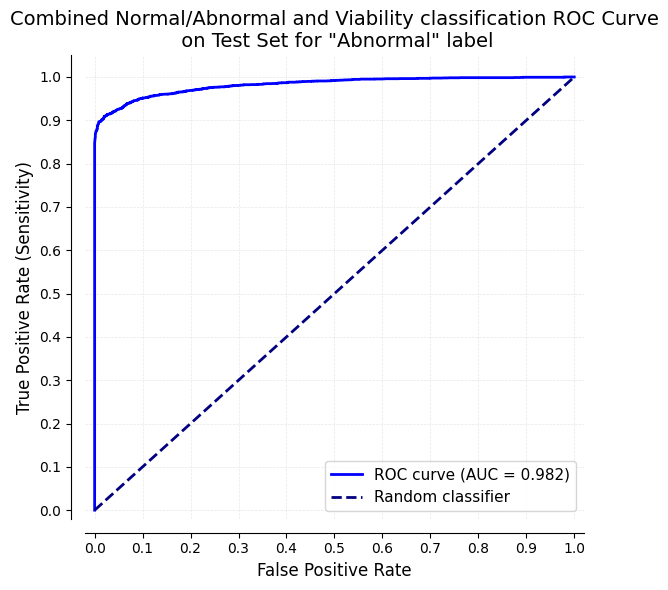

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    confusion_matrix, roc_curve, auc
)

y_true = test_set_for_val_plan_normaldefwviab['FINAL_NORMAL'].astype(int)
y_pred = test_set_for_val_plan_normaldefwviab['FINAL_PREDICTED_NORMAL'].astype(int)
y_scores = test_set_for_val_plan_normaldefwviab['FINAL_MODEL_SCORE']

recall = recall_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
specificity = tn / (tn + fp) if (tn + fp) else 0.0
npv = tn / (tn + fn) if (tn + fn) else 0.0

print(f"Recall: {recall:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"NPV: {npv:.3f}")
print(f"F1: {f1:.3f}")
print(f"Confusion matrix: TP={tp}, FP={fp}, FN={fn}, TN={tn}")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc



fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')

ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
ax.set_xticks(np.arange(0, 1.1, 0.1))
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title(f'Combined Normal/Abnormal and Viability classification ROC Curve\n on Test Set for "Abnormal" label', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# Move spines away from origin
ax.spines['left'].set_position(('outward', 10))
ax.spines['bottom'].set_position(('outward', 10))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

def plot_high_sensitivity_roc(true_label,
                              predicted_scores,
                              sens_min=0.90,
                              num_points=5,
                              figsize=(6, 5),
                              offset_cycle=None,
                              min_fpr_gap=0.02):
    """
    Zoomed ROC with threshold + specificity labels in high-sensitivity region,
    avoiding overlapping labels by enforcing a minimum FPR spacing.
    """

    if offset_cycle is None:
        # a richer default set of offsets
        offset_cycle = [(10, 10), (-10, 10), (10, -10), (-10, -10),
                        (12, 0), (-12, 0)]

    fpr, tpr, thr = roc_curve(true_label, predicted_scores)

    mask = tpr >= sens_min
    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(fpr[mask], tpr[mask], 'b-', alpha=0.75)
    ax.set_xlim(0, max(0.02, fpr[mask].max() if mask.any() else 0.01))
    ax.set_ylim(sens_min - 0.01, 1.01)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('Sensitivity (TPR)')
    ax.set_title(f'Combined Normal/Abnormal and Viability classification ROC Curve\n on Test Set for "Abnormal" label (Sens. ≥ {sens_min:.0%})')
    ax.grid(True, alpha=0.3)

    idxs = np.where(mask)[0]
    if len(idxs):
        # Evenly spaced picks among high-sensitivity indices
        base_picks = np.linspace(0, len(idxs) - 1,
                                 num=min(num_points, len(idxs)),
                                 dtype=int)
        selected = list(idxs[base_picks])

        # Force include some specific thresholds if present
        targets = np.array([0.05, 0.10, 0.15, 0.20])
        for tgt in targets:
            match = np.where(np.isclose(thr[idxs], tgt, atol=1e-3))[0]
            if match.size:
                selected.append(idxs[match[0]])

        # Drop duplicates while preserving order
        seen = set()
        selected = [i for i in selected if not (i in seen or seen.add(i))]

        # Sort by FPR so we can enforce spacing along x-axis
        selected = sorted(selected, key=lambda i: fpr[i])

        # Enforce a minimum distance in FPR between labeled points
        spaced_selected = []
        for i in selected:
            if not spaced_selected or all(abs(fpr[i] - fpr[j]) >= min_fpr_gap
                                          for j in spaced_selected):
                spaced_selected.append(i)
        selected = spaced_selected

        # Finally, annotate
        offsets = offset_cycle
        for k, idx in enumerate(selected):
            dx, dy = offsets[k % len(offsets)]
            spec = 1 - fpr[idx]
            ax.plot(fpr[idx], tpr[idx], 'ko', markersize=5)
            ax.annotate(f"thr={thr[idx]:.4f}\nspec={spec:.3f}",
                        (fpr[idx], tpr[idx]),
                        textcoords='offset points',
                        xytext=(dx, dy),
                        fontsize=8,
                        bbox=dict(boxstyle='round,pad=0.3',
                                  fc='white', ec='gray', alpha=0.9))

    plt.tight_layout()
    plt.show()


# Recall: 0.991
# Precision: 0.827
# Specificity: 0.520
# NPV: 0.961
# F1: 0.901
# Confusion matrix: TP=3221, FP=676, FN=30, TN=733
    

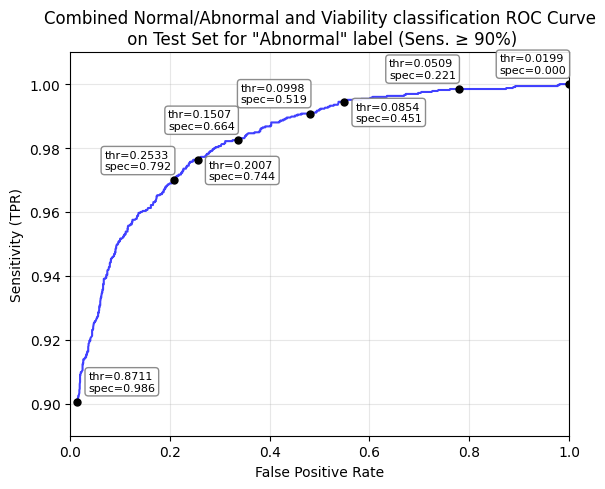

In [15]:
plot_high_sensitivity_roc(
    test_set_for_val_plan_normaldefwviab['FINAL_NORMAL'].astype(int),
    test_set_for_val_plan_normaldefwviab['FINAL_MODEL_SCORE'],
    sens_min=0.90,
    num_points=4,
    figsize=(6, 5),
    offset_cycle=[(8, 8), (-50, 8), (8, -14), (-50, 8), (-50, 8), (8, -14), (-50, 8), (-50, 8)]
)


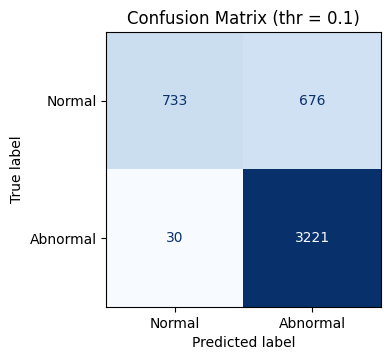

In [16]:

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

threshold = 0.1
y_true = test_set_for_val_plan_normaldefwviab['FINAL_NORMAL'].astype(int)
y_pred = test_set_for_val_plan_normaldefwviab['FINAL_PREDICTED_NORMAL'].astype(int)
scores = test_set_for_val_plan_normaldefwviab['FINAL_MODEL_SCORE']

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Abnormal'])

fig, ax = plt.subplots(figsize=(4, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix (thr = {threshold})')
plt.grid(False)
plt.tight_layout()
plt.show()

In [18]:
test_set_for_val_plan_normaldefwviab.columns

Index(['ACCESSION_x', 'sample_type', 'NORMAL', '10+BNHL', '5+BNHL',
       '5-10-BNHL', 'AML', 'B-NHL', 'BALL', 'CLL', 'Clotted', 'DE', 'DLBCL',
       'Eos', 'GD_Tcells', 'HCL', 'Hematogones', 'Hemodilute', 'High48Ratio',
       'LGL', 'Left Shift', 'MastCell', 'Monocytic', 'Myeloid', 'NK', 'No20',
       'PDC', 'PNH', 'Paucicellular', 'PlasmaCell', 'Reversed48Ratio',
       'Sezary', 'Suboptimal', 'TALL', 'TLPD', 'Weak33', 'N_BNHL', 'N_TLPD',
       'N_Myeloid', 'N_Quality', 'N_AL', 'path', 'ABNORMAL', 'fil',
       'sampleid1', 'testname', 'testfile', 'tot', 'date', 'btime', 'b_cell',
       't_cell', 'myeloid', 'pc', 'tissue1', 'tissue2', 'hairy_cell_mature_b',
       'aml', 'cytoplasmic', 'sezary', 'tcc_tfh', 'mega_v2', 'mastcell',
       'ball_hematogone', 'immaT', 'aml_500', 'ball_hematogone_500', 'b_lbl',
       'ball_hematogone_500k', 'b_lbl_2', 'IS_NORMAL', 'ADD_ON',
       'ACTION_REQUIRED', 'chart_text_x', 'accession', 'true_label',
       'mean_logit', 'std_logit', 'mean_p

In [17]:
def performance_metrics(threshold=0.1):

    true_pos=test_set_for_val_plan_normaldefwviab[(test_set_for_val_plan_normaldefwviab['FINAL_MODEL_SCORE']>threshold) & (test_set_for_val_plan_normaldefwviab['FINAL_NORMAL']==True)]
    false_neg=test_set_for_val_plan_normaldefwviab[(test_set_for_val_plan_normaldefwviab['FINAL_MODEL_SCORE']<threshold) & (test_set_for_val_plan_normaldefwviab['FINAL_NORMAL']==True)]
    false_pos=test_set_for_val_plan_normaldefwviab[(test_set_for_val_plan_normaldefwviab['FINAL_MODEL_SCORE']>threshold) & (test_set_for_val_plan_normaldefwviab['FINAL_NORMAL']==False)]
    true_neg=test_set_for_val_plan_normaldefwviab[(test_set_for_val_plan_normaldefwviab['FINAL_MODEL_SCORE']<threshold) & (test_set_for_val_plan_normaldefwviab['FINAL_NORMAL']==False)]
    l_tp=len(true_pos)
    l_fn=len(false_neg)
    l_fp=len(false_pos)
    l_tn=len(true_neg)
    print('TP', l_tp, 'FN', l_fn, 'FP', l_fp, 'TN', l_tn)
    recall=l_tp/(l_tp+l_fn)
    precision=l_tp/(l_tp+l_fp)
    specificity=l_tn/(l_tn+l_fp)
    npv=l_tn/(l_tn+l_fn)
    f1=2*l_tp/(2*l_tp+l_fp+l_fn)

    print(f"Recall: {recall:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Specificity: {specificity:.3f}")
    print(f"NPV: {npv:.3f}")
    print(f"F1: {f1:.3f}")


In [18]:
performance_metrics(threshold=0.1)

TP 3221 FN 30 FP 676 TN 733
Recall: 0.991
Precision: 0.827
Specificity: 0.520
NPV: 0.961
F1: 0.901


In [19]:
performance_metrics(threshold=0.1)

TP 3221 FN 30 FP 676 TN 733
Recall: 0.991
Precision: 0.827
Specificity: 0.520
NPV: 0.961
F1: 0.901


In [17]:
performance_metrics(threshold=0.2)

Recall: 0.977
Precision: 0.898
Specificity: 0.744
NPV: 0.932
F1: 0.936


In [22]:
performance_metrics(threshold=0.2)

Recall: 0.983
Precision: 0.857
Specificity: 0.622
NPV: 0.940
F1: 0.916
